# General analysis of "true" (simulated by VASP using DFT) trajectories

In [ ]:
# TO DO: re-run whole code AFTER discarding equilibration part of simulation, on new data (note that some parts still need changes; be particularly careful of what "images" variable refers to)??

We study a "Hybrid perovskite" material: two connected SnI6 "inorganic" plus short N-C-C-C-C-N "organic" chains (see Vesta for structure).

Note that Sn has configuration 5s2 5p2, but loses outermost electron pair, hence being able to form six bonds.

In [ ]:
# find predicted (in literature) bond length to double check?

# find a way to see if bond is ionic or covalent?

In [ ]:
!pwd 

/home/libero/LCPB_2026/Project


In [ ]:
# the four following cells to set paths once and for all:

In [1]:
%env OUTCAR_FILE=./new_data/1.NVT_300/A.1_10K/OUTCAR

env: OUTCAR_FILE=./new_data/1.NVT_300/A.1_10K/OUTCAR


In [2]:
%env INCAR_FILE=./new_data/1.NVT_300/A.1_10K/INCAR

env: INCAR_FILE=./new_data/1.NVT_300/A.1_10K/INCAR


In [3]:
outcar_file="./new_data/1.NVT_300/A.1_10K/OUTCAR"
incar_file="./new_data/1.NVT_300/A.1_10K/INCAR"

In [15]:
#!ls ./data

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from ase.io import read
from ase.io import iread
from ase.geometry.rdf import get_rdf
from ase.neighborlist import neighbor_list
from ase.geometry import find_mic
import ase.units as units
import os

## Visualize simulation cell

In [5]:
#atoms = read('data/OUTCAR')  # or XDATCAR, POSCAR
atoms= read(outcar_file)


In [ ]:
print("Vectors defining cell:", atoms.get_cell())

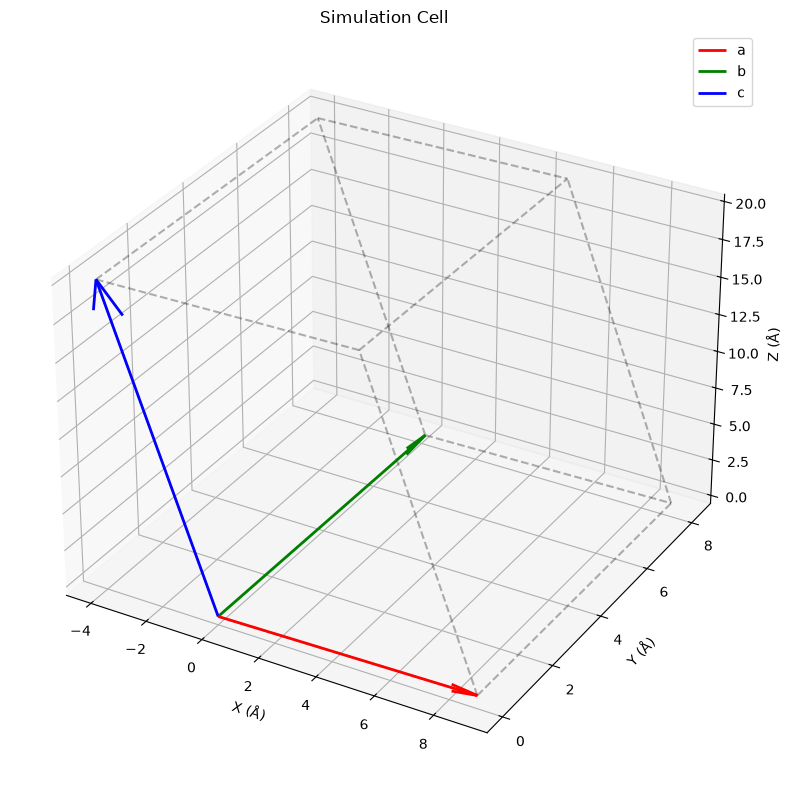

Cell lengths: |a|=8.82, |b|=8.12, |c|=20.43 Å
Volume: 1436.22 Å³


In [71]:
cell = np.array([[8.821499604, 0.139523419, -0.006187493],
                 [0.02934784, 8.1225709, -0.148571588],
                 [-3.959903978, 0.0, 20.046764181]])

a, b, c = cell
origin = np.zeros(3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw vectors
for vec, color, label in zip([a, b, c], ['r', 'g', 'b'], ['a', 'b', 'c']):
    ax.quiver(*origin, *vec, color=color, arrow_length_ratio=0.1, linewidth=2, label=label)

# Draw cell edges
corners = np.array([
    origin,
    a, b, c,
    a+b, a+c, b+c,
    a+b+c
])

edges = [
    (0,1), (0,2), (0,3),  # from origin
    (1,4), (1,5),  # from a
    (2,4), (2,6),  # from b
    (3,5), (3,6),  # from c
    (4,7), (5,7), (6,7)   # to opposite corner
]

for i, j in edges:
    ax.plot(*zip(corners[i], corners[j]), 'k--', alpha=0.3)

ax.set_xlabel('X (Å)')
ax.set_ylabel('Y (Å)')
ax.set_zlabel('Z (Å)')
ax.legend()
ax.set_title('Simulation Cell')
plt.tight_layout()
plt.show()

print(f"Cell lengths: |a|={np.linalg.norm(a):.2f}, |b|={np.linalg.norm(b):.2f}, |c|={np.linalg.norm(c):.2f} Å")
print(f"Volume: {np.abs(np.dot(a, np.cross(b, c))):.2f} Å³")

Note: the box is the "unit cell" of the simulation - there's exactly one in the calculation.

3x3x3=27 cells are repeated in space, and interactions must be accounted for considering the closest n atoms (or all atoms within a certain distance) in neighboring cells also.

VASP is (almost) exact as it uses DFT; distance cutoffs (not strictly "interaction" cutoffs) are applied in limited circumstances:

In [23]:
!grep "cutoff" $OUTCAR_FILE | sort -u # unique

   ENAUG  =  644.9 eV  augmentation charge cutoff
   ENINI  =  400.0     initial cutoff
   NGX,Y,Z   is equivalent  to a cutoff of  11.41, 11.05, 11.40 a.u.
   NGXF,Y,Z  is equivalent  to a cutoff of  22.82, 22.11, 22.79 a.u.
   RCLOC  =    0.701    cutoff for local pot                                                        
   RCORE  =    1.100    outmost cutoff radius                                                       
   RCORE  =    1.500    outmost cutoff radius                                                       
   RCORE  =    2.300    outmost cutoff radius                                                       
   RCORE  =    2.500    outmost cutoff radius                                                       
  energy-cutoff  :      400.00


In [ ]:
# IMPORTANT NOTE: in future analysis, the first 5000 steps are equilibration so they should be discarded immediately

# TODO: try same analysis on new data?
# 
# TODO: write func definitions? (AFTER understaing MACE output as well)

## RDF-based analysis

The Radial Distribution Function, usually denoted as $g(r)$, is a fundamental structural tool used in physics and materials science to describe how atoms are spatially packed around one another.

Imagine choosing one specific atom in your system as a "central reference atom." You then draw a series of thin, concentric spherical shells of radius r and thickness Δr around it. The RDF measures the local *atomic* density within these shells compared to the overall average density of the system.

RDF plot will have highly distinct, recognizable features:

    Sharp, Discrete Peaks: Crystals possess highly periodic, long-range structural order. Because atoms sit at fixed positions, they only exist at very specific distances from each other. RDF will show sharp "spikes" or peaks at those precise geometric distances, corresponding to the 1st nearest neighbors, 2nd nearest neighbors, and so on.

    Zero-Probability Gaps: Between these peaks, g(r) will drop exactly to 0, because the rigid crystal structure dictates that no atoms can physically exist in the spaces between the designated lattice sites.

    Long-Range Order: Unlike liquids or amorphous materials—where the peaks quickly smooth out and flatten to a value of 1.0 at long distances—a perfect crystal will continue to display sharp peaks even at very large values of r.



We compute other quantities:

1. Integrated Coordination Number ($N_c$)

The standard Radial Distribution Function $g(r)$ tells you the relative probability of finding atoms at a distance $r$, but it does not directly count them. The Integrated Coordination Number solves this by summing up the actual number of atoms.Mathematically, it is defined as:$$N_c(R) = 4\pi \rho \int_0^R r^2 g(r) dr$$

Where $\rho$ is the total number density of the crystal (total atoms divided by cell volume).

2. Potential of Mean Force (PMF)The Potential of Mean Force

denoted as $W(r)$, is a thermodynamic quantity that translates structural probabilities into an energy landscape. It is derived directly from the fluid/solid structure using the Boltzmann inversion:$$W(r) = -k_B T \ln [g(r)]$$Where $k_B$ is the Boltzmann constant and $T$ is the simulation temperature.

Physical Meaning for the Whole Crystal

Free Energy Landscape: $W(r)$ represents the effective free energy profile of the system as a function of interatomic distance. It accounts not just for the direct electrostatic and Van der Waals forces between two specific atoms, but also for the "mean" average influence exerted by all the surrounding atoms in the crystal matrix.

Interpreting the Minima: Every peak in total $g(r)$ becomes a local energy minimum (a well) in $W(r)$. The deepest wells correspond to the most stable chemical bonds in the system . The curvature at the bottom of these wells tells you about bond stiffness: a narrow, sharp well means a rigid, highly stable bond, while a broad well implies a soft, flexible interaction that allows for large thermal vibrations.

3. Rolling Window Peak Tracking ($g_{max}$ and FWHM)

Unlike the first two quantities which are averaged over the entire simulation, this is a kinetic and temporal diagnostic. It splits the trajectory into small chronological segments (windows) and extracts two critical shape features from the highest peak of the $g(r)$:

- $g_{max}$ (Peak Height): The absolute maximum value of the primary peak in that specific time window.

- FWHM (Full Width at Half Maximum): The width of the peak measured at exactly half of its maximum height.

Physical Meaning for the Whole Crystal

Tracking Crystallinity ($g_{max}$): The height of an RDF peak reflects structural order. If material is highly crystalline and well-ordered, atoms sit precisely at fixed distances, making the peaks incredibly tall. If $g_{max}$ rises during the simulation, your crystal is ordering itself. If it drops significantly, it means the structure is becoming disordered, amorphized, or undergoing a structural transition.

Tracking Thermal Fluctuations (FWHM): The width of the peak is a measure of atomic displacement and thermal shaking. A broadening peak (higher FWHM) means atoms are vibrating more violently around their equilibrium positions, which typically happens if the temperature spikes or if the structural framework is softening.

The Ultimate Equilibrium Test: When plotting these two metrics against time, they should ideally converge into flat, horizontal lines. The exact frame where $g_{max}$ and FWHM stop drifting and stabilize into a steady state marks the exact moment your simulation reached true thermodynamic equilibrium.

In [ ]:
#%run ASE_copy.py

Retriver 5406 structures from OUTCAR.
File saved as ./data/cleaned_dataset.extxyz


In [6]:
from useful_functions import clean_dataset

In [7]:
my_full_file="./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz" # unzipped (one line from terminal)

In [ ]:
# in case not already existing:
clean_dataset(
    outcar_file=outcar_file,
    destination_file=my_full_file,
)

Retrieved 10000 structures from OUTCAR.
File saved as ./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz


0

In [8]:
! ls -lhS $(dirname $OUTCAR_FILE) # biggest first

total 971M
-rw-r--r-- 1 libero libero 490M Apr 19 07:00 OUTCAR
-rw-r--r-- 1 libero libero 158M Apr 19 07:00 vasprun.xml
-rw-r--r-- 1 libero libero 104M Aug  8 11:50 cleaned_dataset.extxyz
-rw-r--r-- 1 libero libero  94M Aug  7 14:12 train.extxyz
-rw-r--r-- 1 libero libero  55M Apr 19 07:00 vaspout.h5
-rw-r--r-- 1 libero libero  39M Jun  8 08:51 XDATCAR
-rw-r--r-- 1 libero libero  11M Aug  7 14:12 valid.extxyz
-rw-r--r-- 1 libero libero 7.7M Apr 19 07:00 out.log
-rw-r--r-- 1 libero libero 7.2M Apr 19 07:00 OSZICAR
-rw-r--r-- 1 libero libero 5.9M Apr 19 07:00 REPORT
-rw-r--r-- 1 libero libero 989K Jun  8 08:48 POTCAR
-rw-r--r-- 1 libero libero  29K Jun  8 08:48 PCDAT
-rw-r--r-- 1 libero libero  26K Jun  8 08:48 CONTCAR
-rw-r--r-- 1 libero libero  22K Jun  8 08:48 DOSCAR
-rw-r--r-- 1 libero libero  12K Jun  8 08:48 POSCAR
-rw-r--r-- 1 libero libero 8.1K Jun  8 08:48 EIGENVAL
-rw-r--r-- 1 libero libero 6.5K Jun  8 08:48 slurm-40131987.out
-rw-r--r-- 1 libero libero 1.1K Jun  8 08:48 INCAR


In [56]:
#?get_rdf

In [9]:
images = read(my_full_file, index=':')

In [10]:
rmax = 3.9 # maximum distance for RDF (angstrom) ---> ok bc max possible with current cell dimension (error otherwise)


In [ ]:

nbins = 1000

all_rdfs = []
distances = None


for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins) # RDF for EACH individual atom, averaged over all atoms...
    # ok, no need to consider individual atoms (would be too noisy)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0) # ...averaged over time steps


number of RDF values: 1000


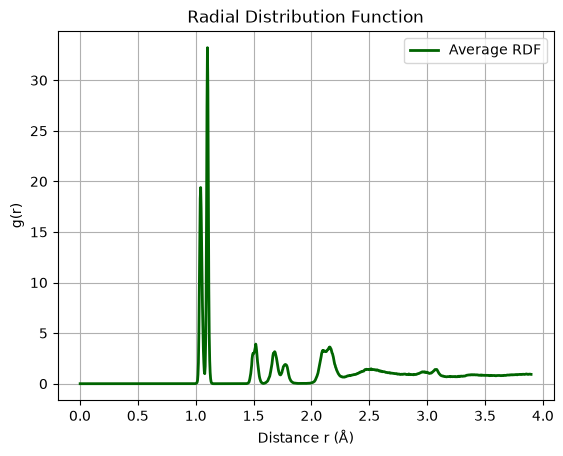

In [29]:

print("number of RDF values:", len(rdf_values))

plt.plot(distances, avg_rdf, color='darkgreen', lw=2, label='Average RDF')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function')
plt.grid(True)
plt.legend()
plt.show()

1 A
Extremely sharp, intense peak corresponds to the C-H and N-H covalent bonds within your organic cations.
Because Hydrogen is highly abundant in the organic part and these covalent bonds are incredibly rigid with very little distance variation, they create a massive, highly localized probability spike.

1.5 A
This peak corresponds precisely to the C-N covalent bonds inside the organic molecules.
Physical Meaning: It is completely separated from the hydrogen peaks, showing that the organic molecules maintain their molecular integrity throughout your entire time series.

2.5 - 3.8 A
Sn-I Bonds (3.1−3.2 A˚): The main component of this broad mountain is the coordination bond between Tin and Iodine, forming the corners of the SnI6​ octahedra.
Hydrogen Bonding (2.5−3.0 A˚): The leading edge of this broad feature captures the weak hydrogen interactions (N-H…I and C-H…I) where the organic molecules "anchor" themselves to the inorganic cage.
Intermolecular Organic Distances: Non-bonded distances between different parts of the organic cations also contribute to the background noise here.


The Sharp Peaks (<2.0 A˚): Covalent intramolecular bonds are very strong. Even at room temperature, the atoms do not vibrate far from their equilibrium positions, keeping the peaks narrow.

The Broad Peaks (>2.5 A˚): The inorganic lattice (Sn-I) and the hydrogen bonds are much softer and flexible. As your time series progresses, thermal energy causes the SnI6​ octahedra to tilt, distort, and vibrate significantly. This structural flexibility smears out the probability, turning what would be sharp crystal spikes at 0 K into a broad, continuous distribution at finite temperatures.

Plot in different moments, to understand the occurences of phase transitions

In [30]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
total_frames = len(images)
chunk_size = total_frames // 4

start_images = images[:chunk_size]
end_images = images[-chunk_size:]

# rmax = 3.9
# nbins = 1000

start_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
    start_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


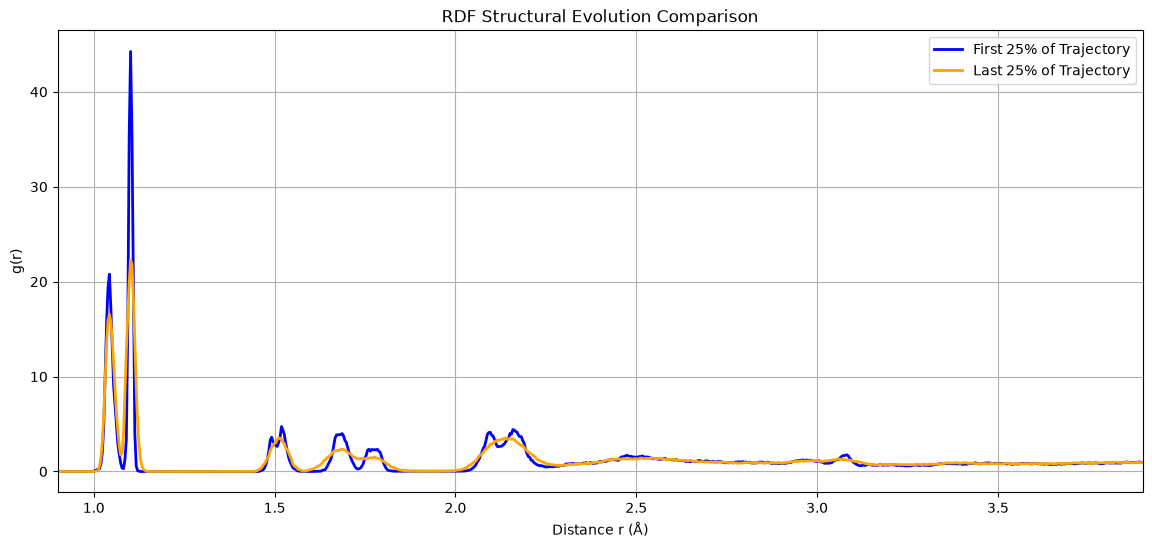

In [35]:
plt.figure(figsize=(14, 6)) 
plt.xlim([0.9,3.9])
plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='First 25% of Trajectory')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='Last 25% of Trajectory')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title('RDF Structural Evolution Comparison')
plt.grid(True)
plt.legend()
plt.show()

The curves are overlapped --> no phase transition

In [ ]:
# NEW DATA WAS USED ONLY UP TO HERE

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
# nbins = 100
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

reference_atoms = images[0] # first time step
volume = reference_atoms.get_volume()
num_target_atoms = len(reference_atoms)
print("N atoms: ", num_target_atoms, "in volume:", volume)
number_density = num_target_atoms / volume

dr = distances[1] - distances[0] # delta-distances between consecutive time steps
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr
# "coord number" of a central atom in a molecule or crystal is the number of atoms, molecules or ions bonded to it
# (ONLY MEANINGFUL FOR INORGANIC) 

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan # convert infs to nans

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


KeyboardInterrupt: 

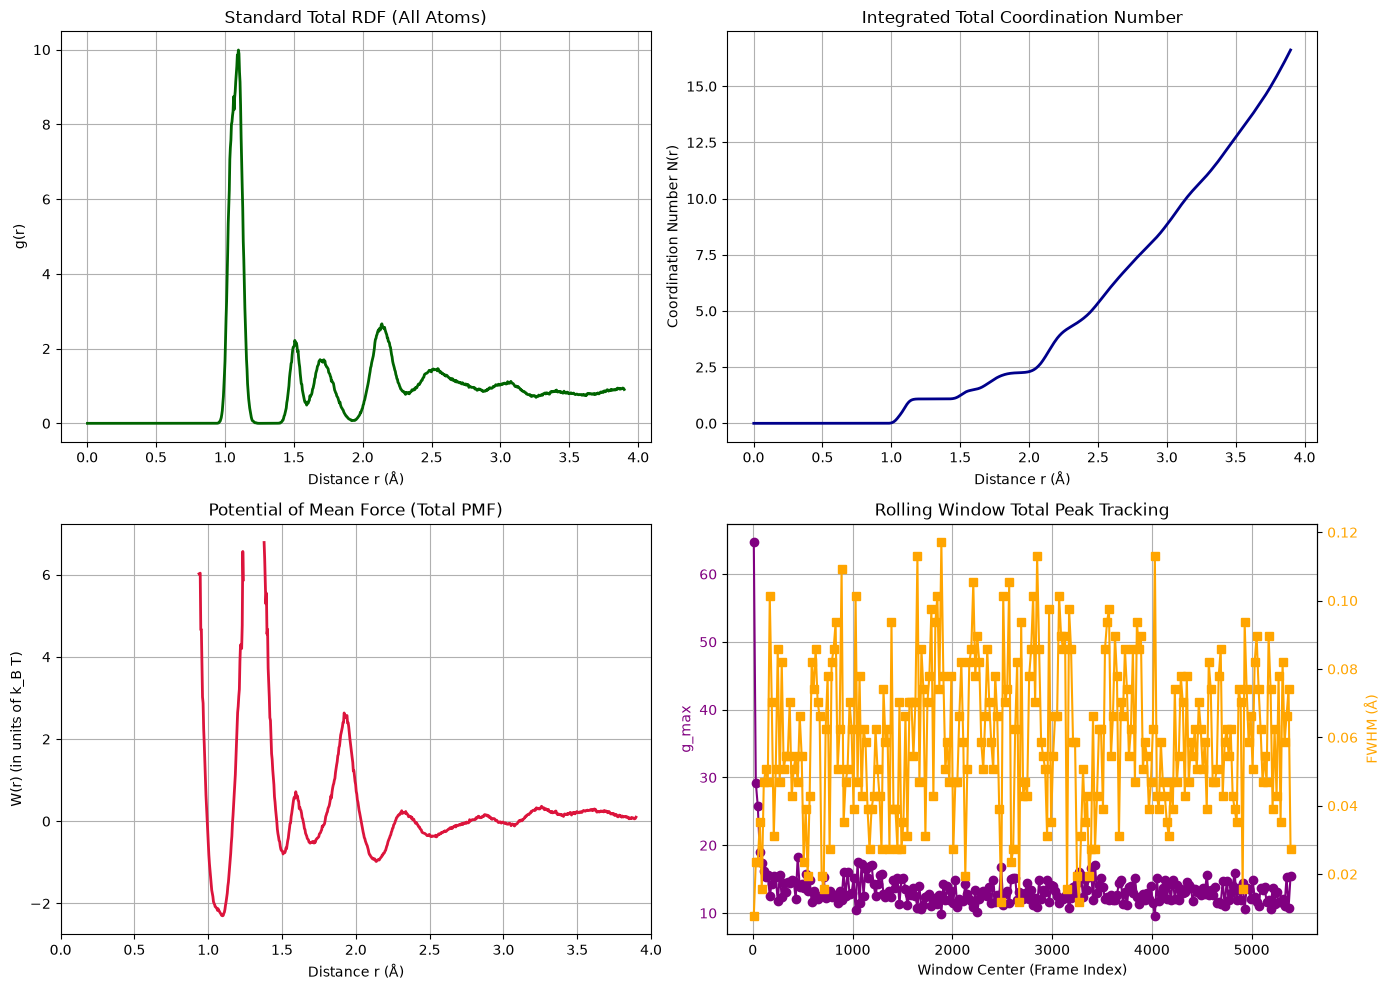

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[1,0].set_xlim([0., 4.])
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title('Standard Total RDF (All Atoms)')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Total Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1,0].set_xlim([0., 4.])
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (Total PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Total Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

Now we want to study the different atoms (we take individual pairs):

### INORGANIC CAGE

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('Sn', 'I')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


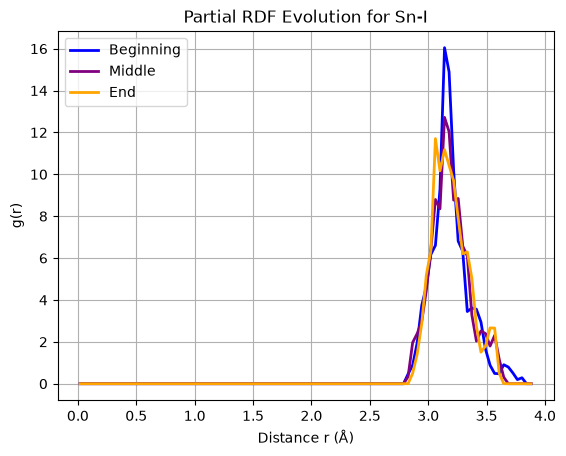

In [ ]:

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('Sn', 'I')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

# vectorize instead? (takes several minutes like this...)
for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


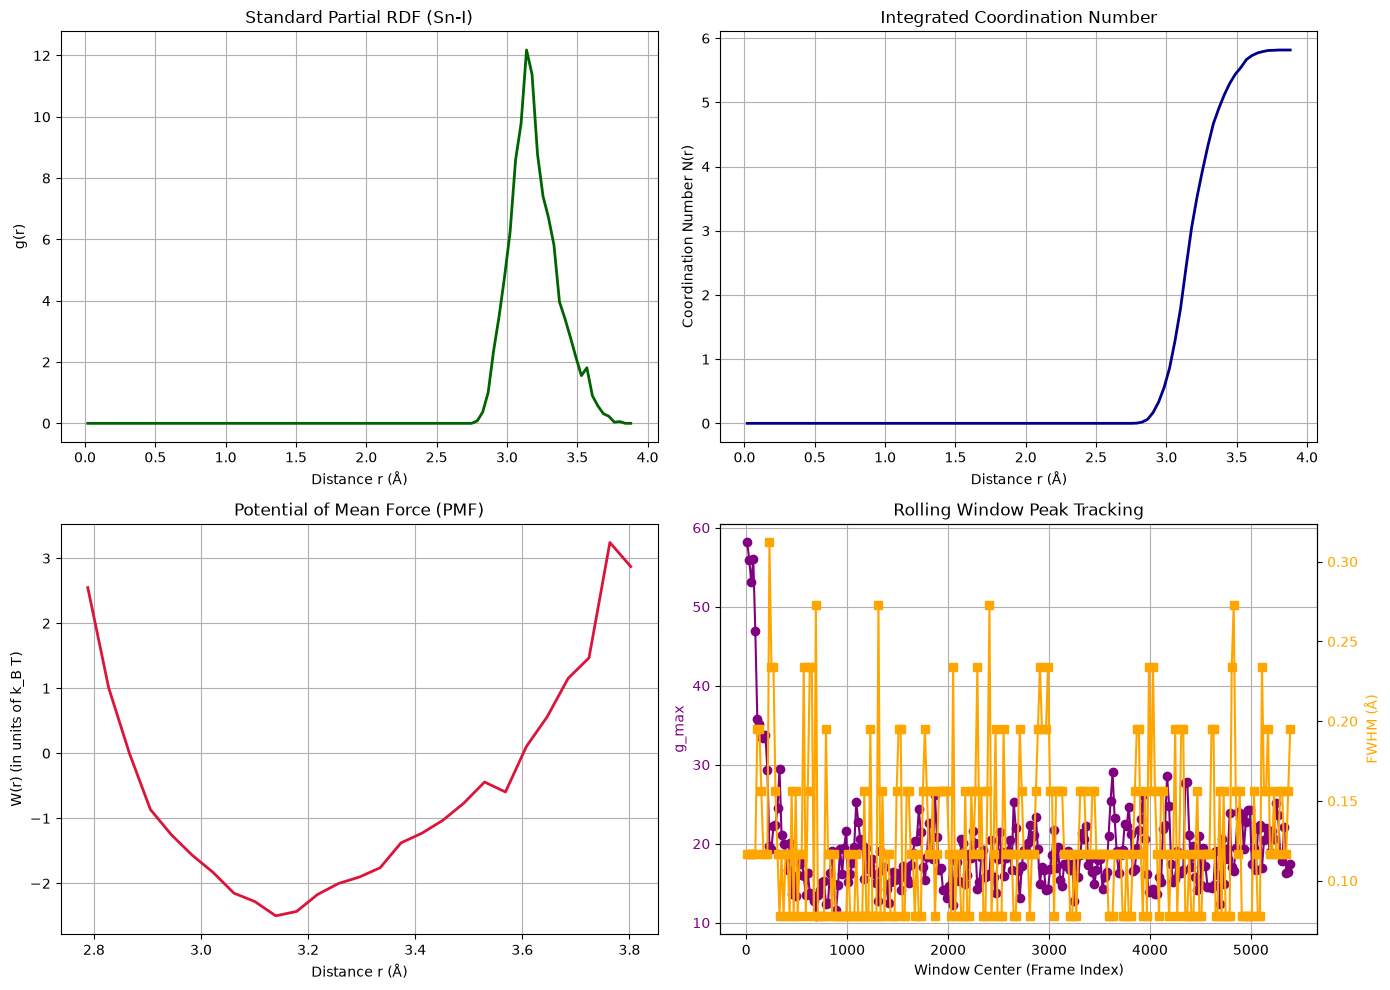

In [ ]:
# NB meaningful: 6 I atoms around Sn
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Sn-Sn does not exist! (look at VESTA!)

# # import numpy as np
# # import matplotlib.pyplot as plt
# # from ase.io import read
# # from ase.geometry.rdf import get_rdf

# # images = read('dataset_clean.extxyz', index=':')
# # total_frames = len(images)
# chunk_size = total_frames // 5

# start_images = images[:chunk_size]
# mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
# end_images = images[-chunk_size:]

# # rmax = 3.9
# nbins = 100
# selected_elements = ('Sn', 'Sn')

# start_rdfs = []
# mid_rdfs = []
# end_rdfs = []
# distances = None

# for atoms in start_images:
#     rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
#     start_rdfs.append(rdf_values)

# for atoms in mid_images:
#     rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
#     mid_rdfs.append(rdf_values)

# for atoms in end_images:
#     rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
#     end_rdfs.append(rdf_values)

# avg_rdf_start = np.mean(start_rdfs, axis=0)
# avg_rdf_mid = np.mean(mid_rdfs, axis=0)
# avg_rdf_end = np.mean(end_rdfs, axis=0)


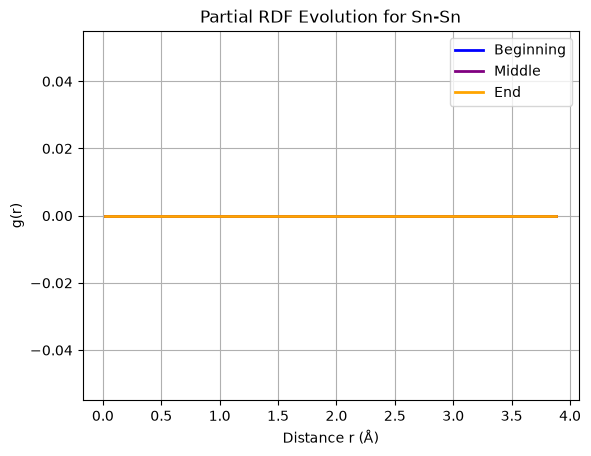

In [ ]:

# plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
# plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
# plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
# plt.xlabel('Distance r (Å)')
# plt.ylabel('g(r)')
# plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
# plt.grid(True)
# plt.legend()
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('I', 'I')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


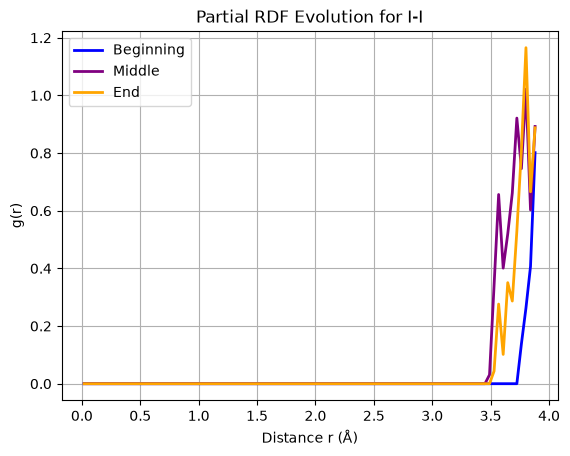

In [ ]:

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

images = read('data/cleaned_dataset.extxyz', index=':')
total_frames = len(images)

rmax = 3.9
nbins = 100
selected_elements = ('I', 'I') # automatically excludes bond with self
# meaningful because: distance between neigthboring octaedra (does NOT exist as bond)
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

reference_atoms = images[0]
volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:
# TAKES 12 minutes on CPU!

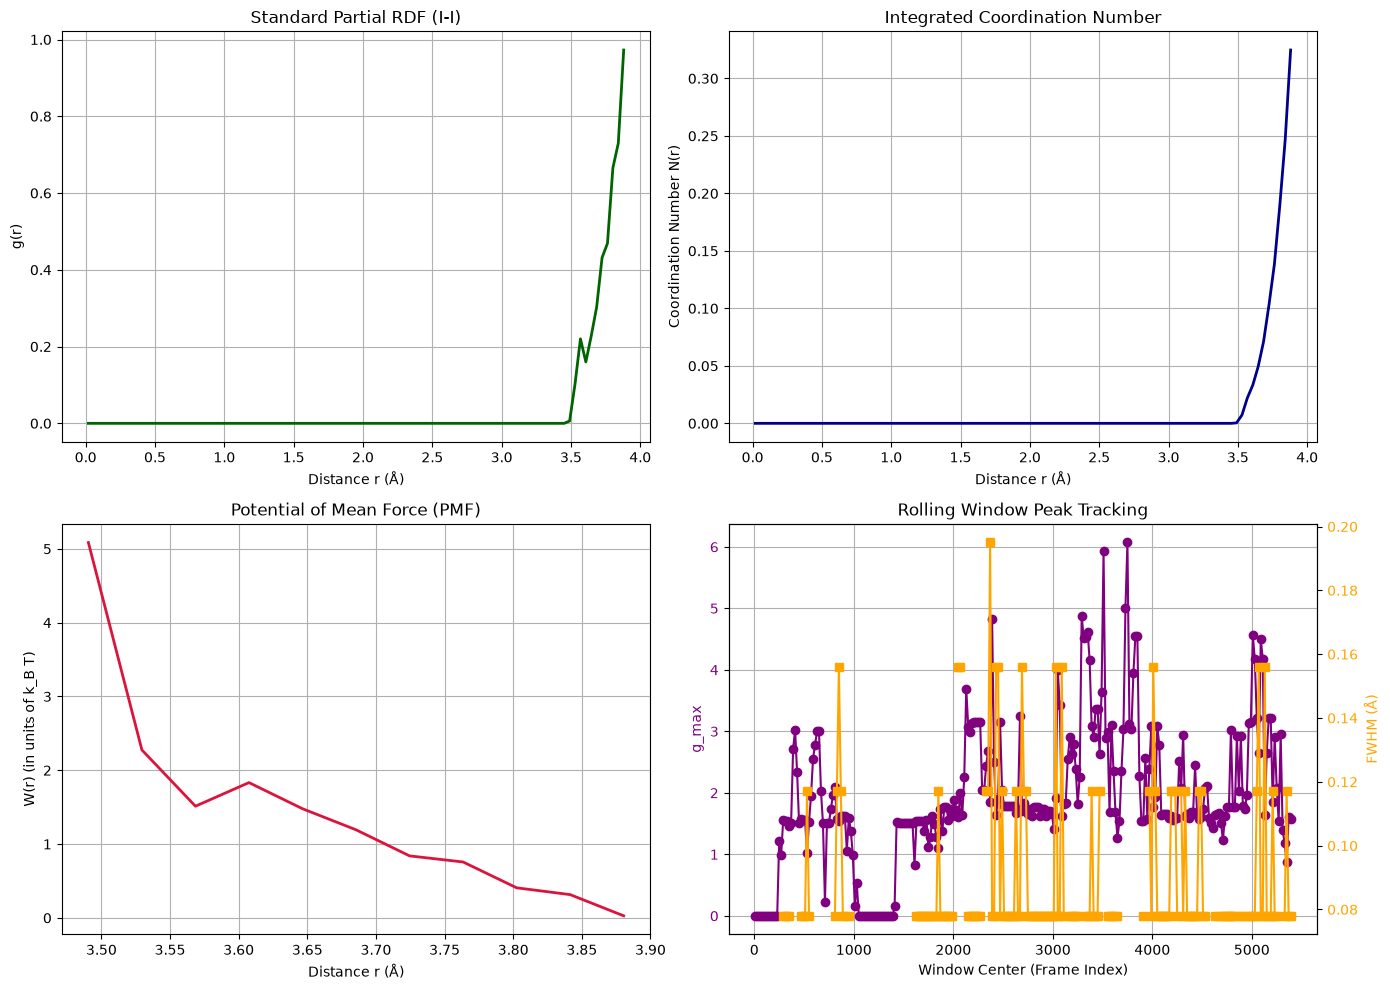

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

### INTERACTION ORGANIC INORGANIC

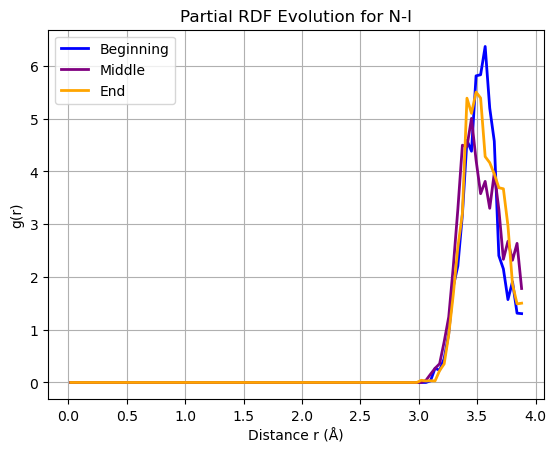

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('N', 'I')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


In [ ]:

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

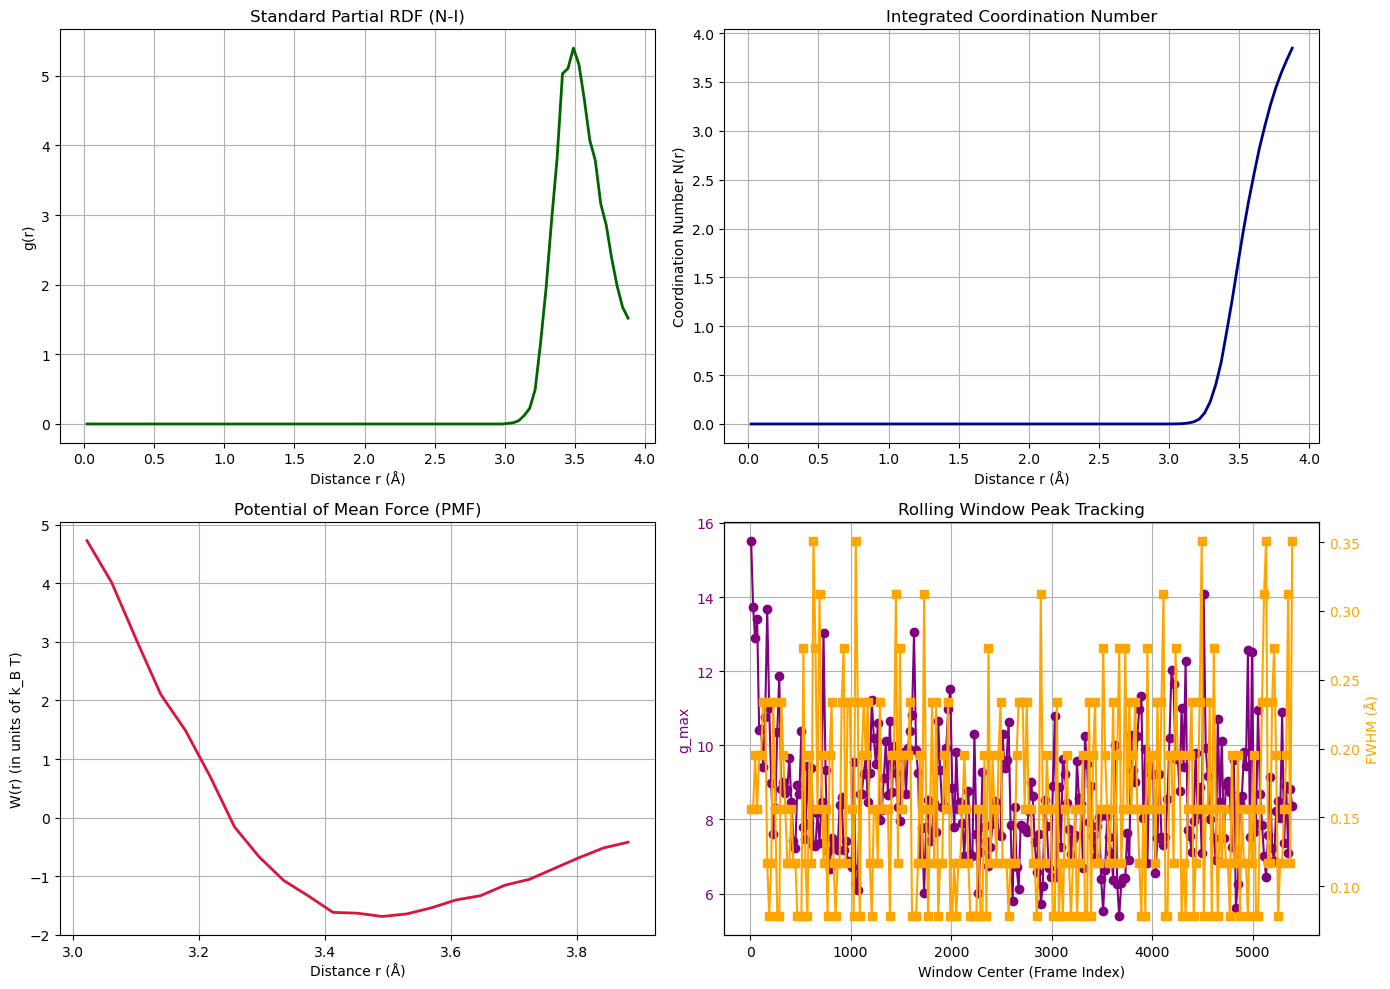

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('N', 'I')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:
# end of inorganic chain to closest I ( fixed length)

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

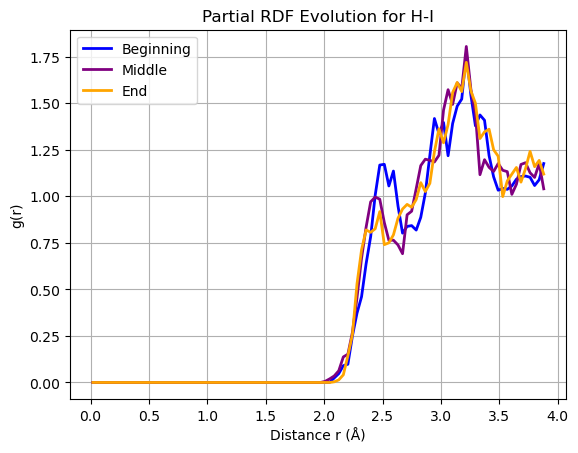

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'I')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


In [ ]:

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

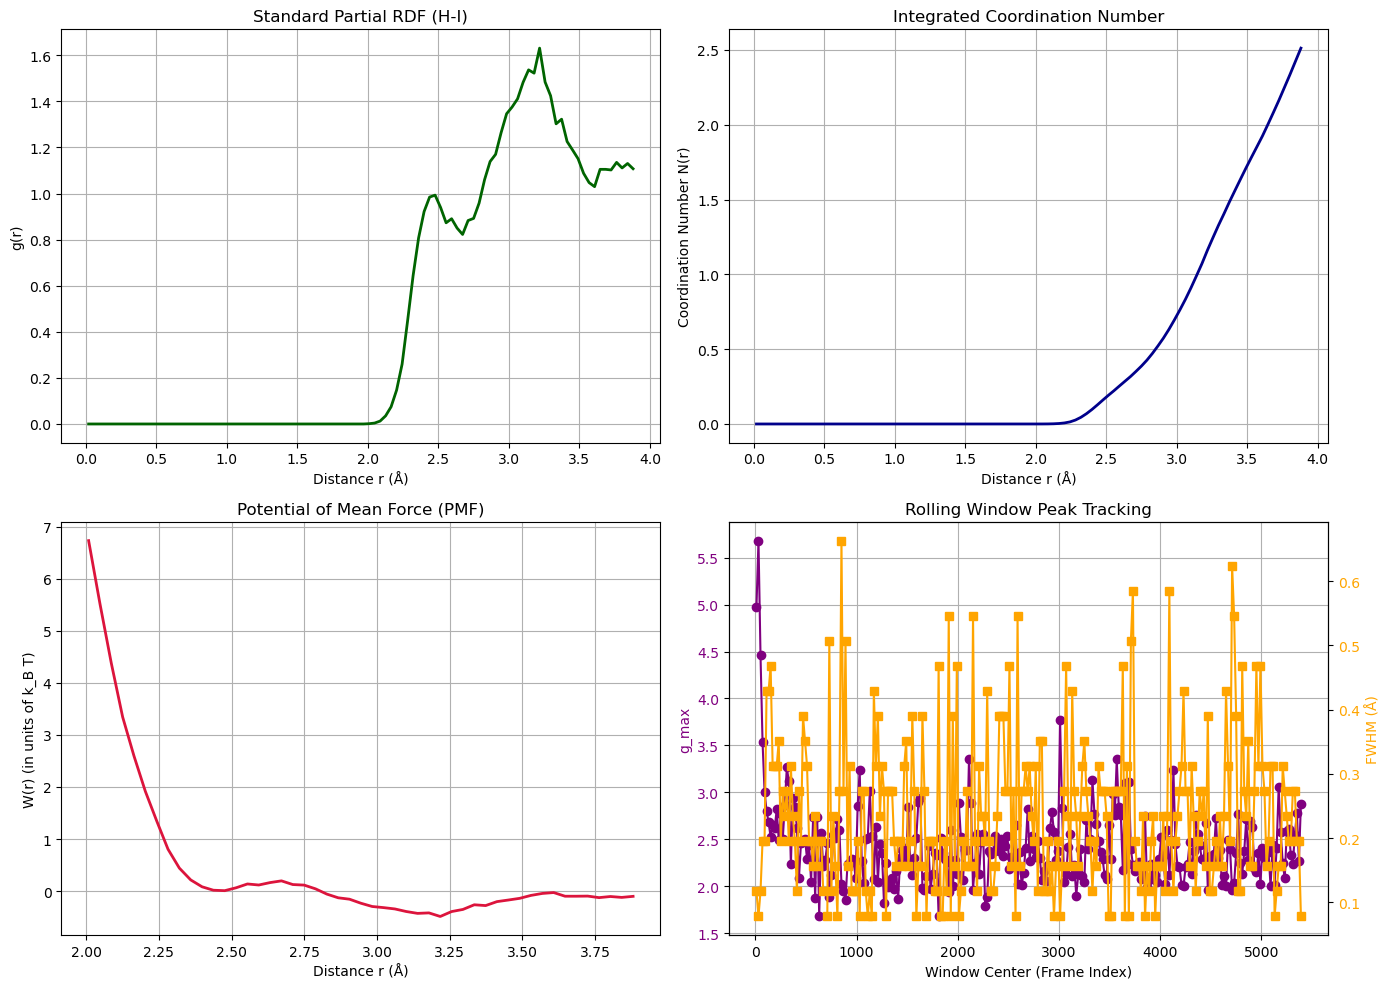

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'I')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:
# not-so-meaningful

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

### ORGANIC PART

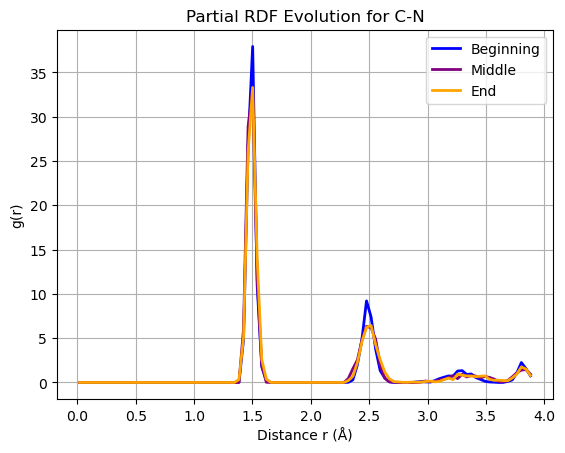

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('C', 'N')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)


In [ ]:

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

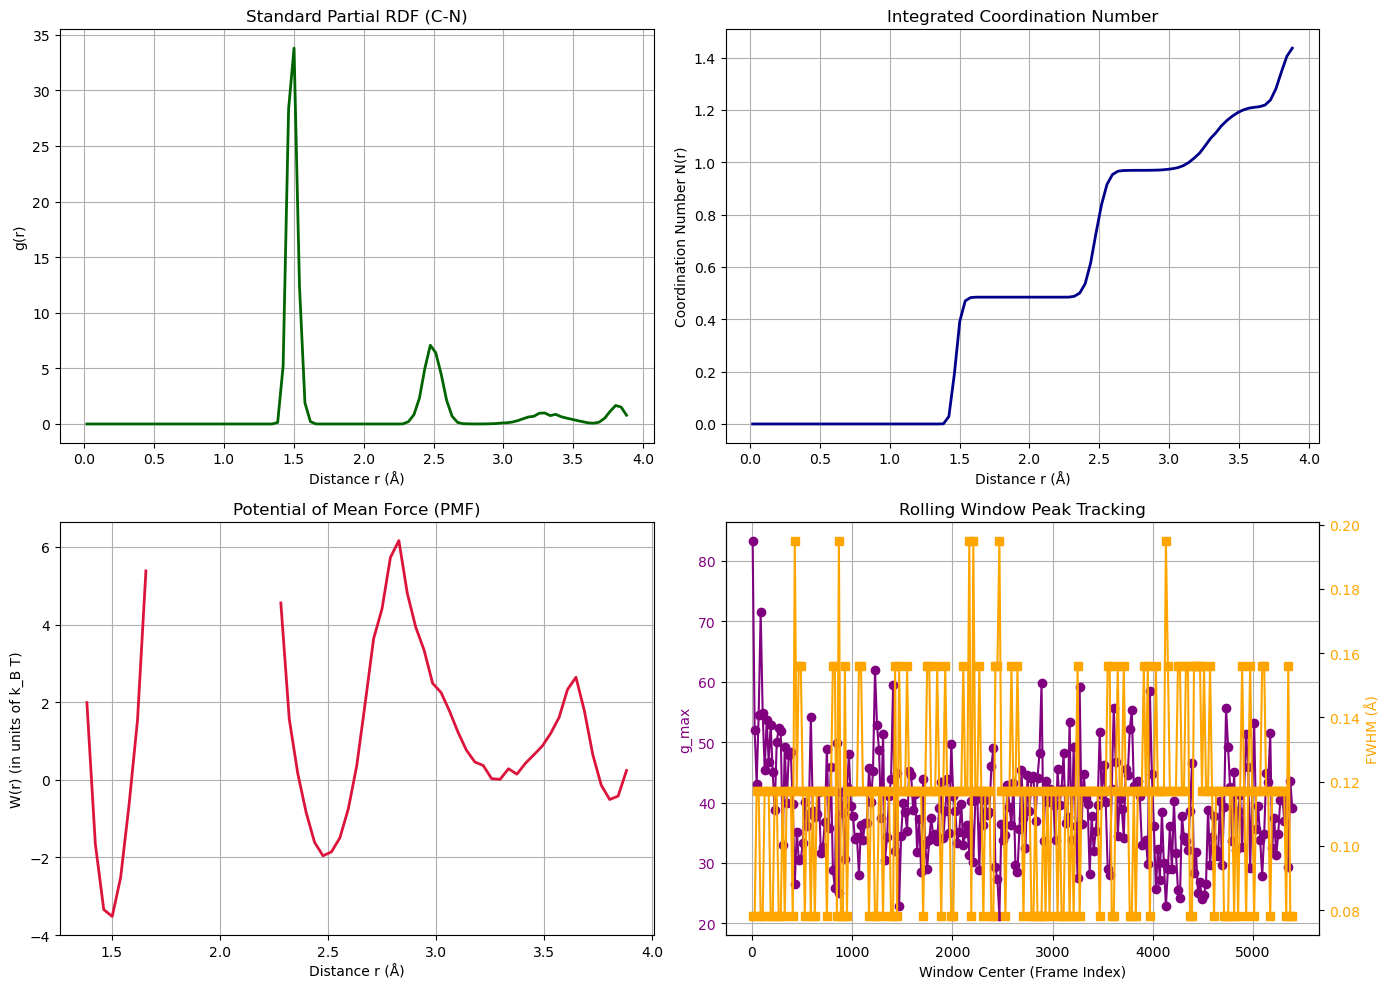

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('C', 'N')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:
# first peak is C-N bond in organic chain, second is C vs N at the other end of the chain, and other two likely C vs N from other chains

In [ ]:
# for this and other ones, check gmax and FWHM **at convergence** (periodicity?)??



In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

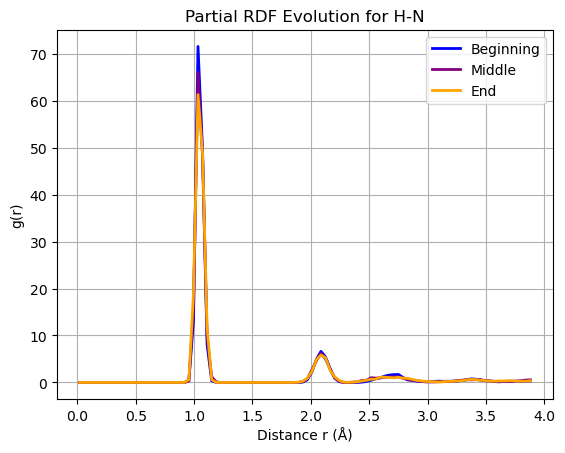

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'N')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

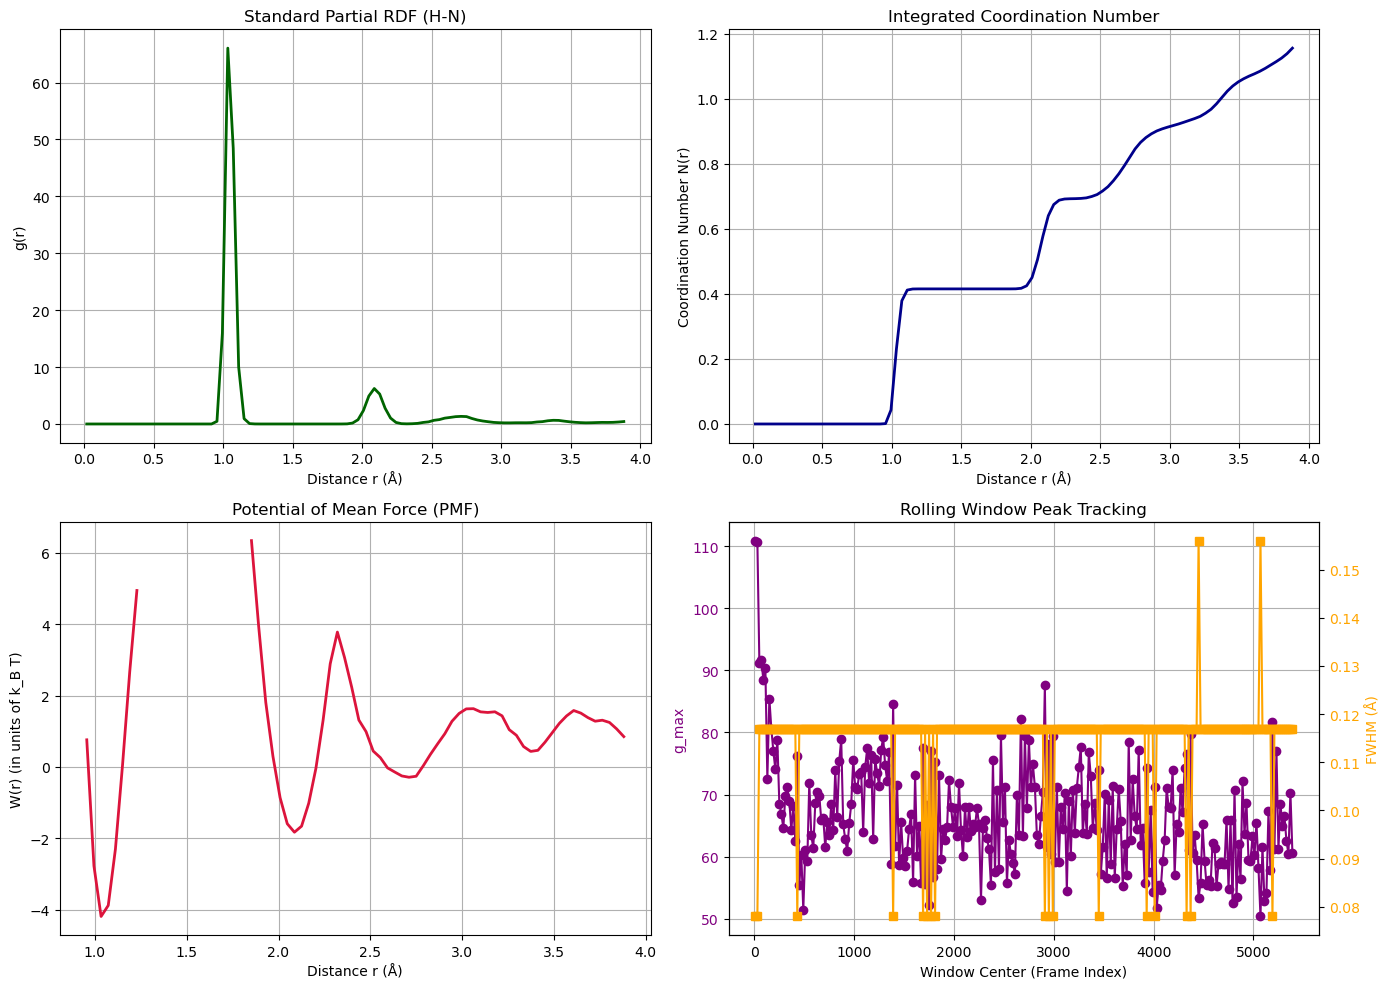

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'N')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

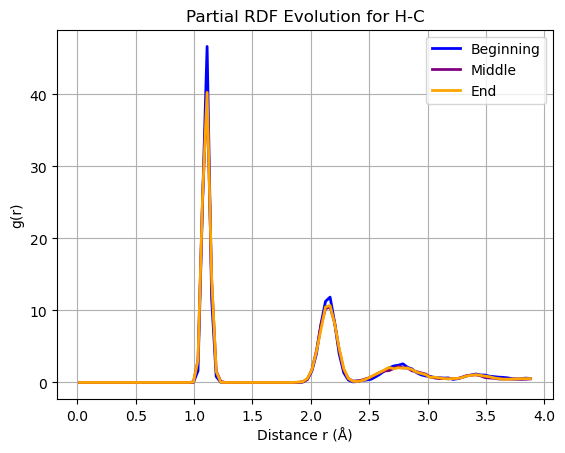

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)
chunk_size = total_frames // 5

start_images = images[:chunk_size]
mid_images = images[total_frames // 2 - chunk_size // 2 : total_frames // 2 + chunk_size // 2]
end_images = images[-chunk_size:]

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'C')

start_rdfs = []
mid_rdfs = []
end_rdfs = []
distances = None

for atoms in start_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    start_rdfs.append(rdf_values)

for atoms in mid_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    mid_rdfs.append(rdf_values)

for atoms in end_images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    end_rdfs.append(rdf_values)

avg_rdf_start = np.mean(start_rdfs, axis=0)
avg_rdf_mid = np.mean(mid_rdfs, axis=0)
avg_rdf_end = np.mean(end_rdfs, axis=0)

plt.plot(distances, avg_rdf_start, color='blue', lw=2, label='Beginning')
plt.plot(distances, avg_rdf_mid, color='purple', lw=2, label='Middle')
plt.plot(distances, avg_rdf_end, color='orange', lw=2, label='End')
plt.xlabel('Distance r (Å)')
plt.ylabel('g(r)')
plt.title(f'Partial RDF Evolution for {selected_elements[0]}-{selected_elements[1]}')
plt.grid(True)
plt.legend()
plt.show()

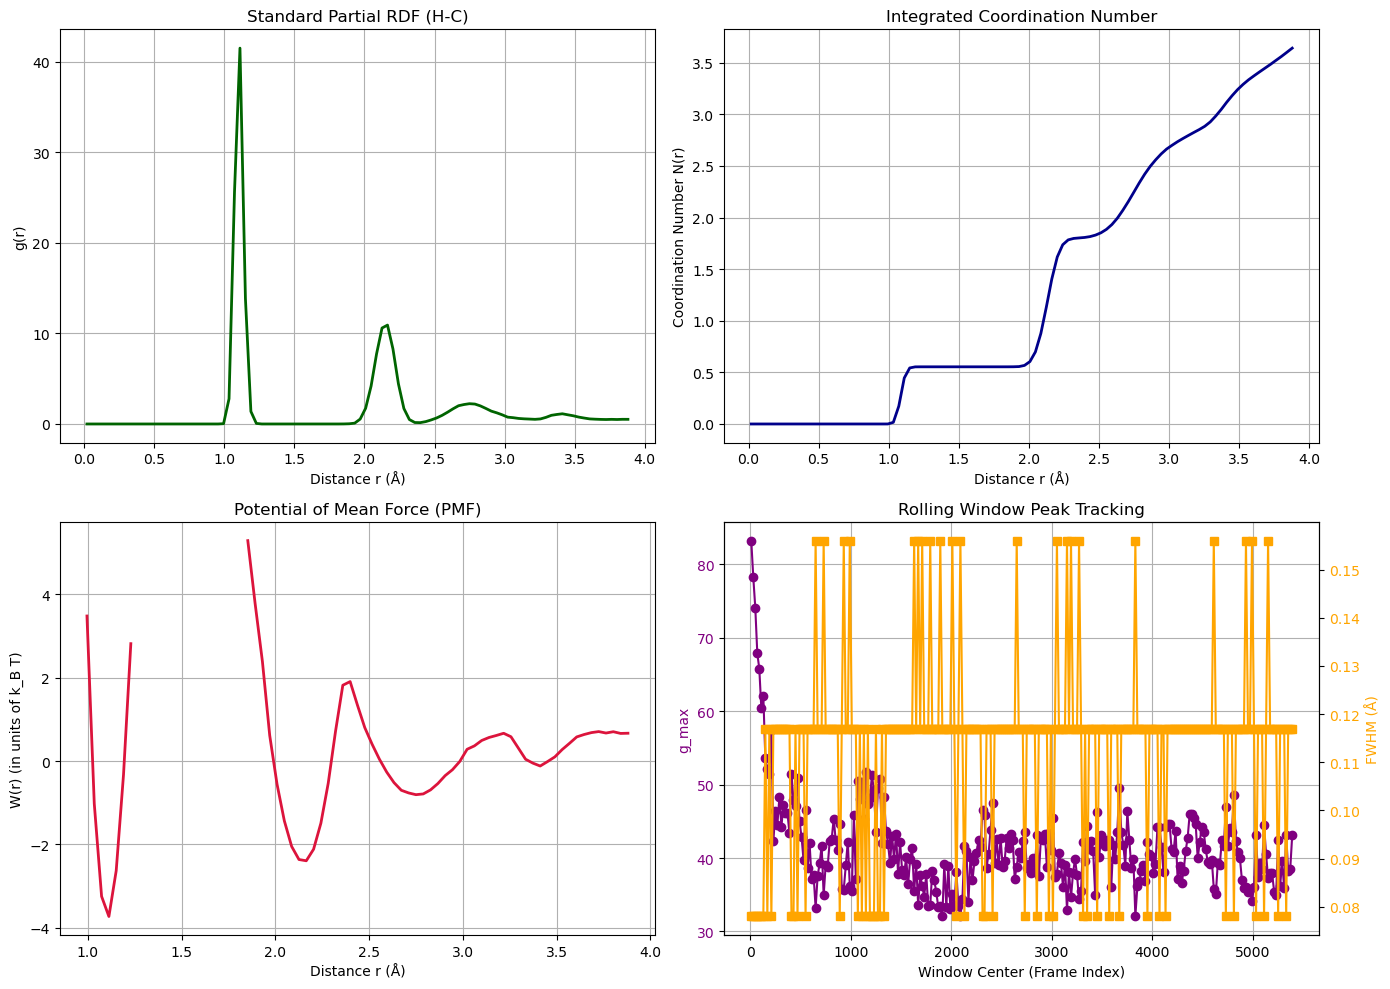

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.geometry.rdf import get_rdf

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# rmax = 3.9
nbins = 100
selected_elements = ('H', 'C')
window_size = 20

all_rdfs = []
distances = None

for atoms in images:
    rdf_values, distances = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
    all_rdfs.append(rdf_values)

avg_rdf = np.mean(all_rdfs, axis=0)

# reference_atoms = images[0]
# volume = reference_atoms.get_volume()
symbols = reference_atoms.get_chemical_symbols()
num_target_atoms = symbols.count(selected_elements[1])
number_density = num_target_atoms / volume

dr = distances[1] - distances[0]
coordination_integrand = 4 * np.pi * number_density * (distances**2) * avg_rdf
coordination_number = np.cumsum(coordination_integrand) * dr

with np.errstate(divide='ignore'):
    pmf = -np.log(avg_rdf)
pmf[np.isinf(pmf)] = np.nan

time_steps = []
g_max_history = []
fwhm_history = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_images = images[start_idx : start_idx + window_size]
    window_rdfs = []
    
    for atoms in window_images:
        rdf_vals, _ = get_rdf(atoms, rmax=rmax, nbins=nbins, elements=selected_elements)
        window_rdfs.append(rdf_vals)
        
    window_avg_rdf = np.mean(window_rdfs, axis=0)
    
    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0
    
    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    
    if len(left_indices) > 0 and len(right_indices) > 0:
        r_left = distances[left_indices[-1]]
        r_right = distances[max_idx + right_indices[0]]
        fwhm = r_right - r_left
    else:
        fwhm = np.nan
        
    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)


In [ ]:
# firs peak is C-H bond

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(distances, avg_rdf, color='darkgreen', lw=2)
axs[0, 0].set_xlabel('Distance r (Å)')
axs[0, 0].set_ylabel('g(r)')
axs[0, 0].set_title(f'Standard Partial RDF ({selected_elements[0]}-{selected_elements[1]})')
axs[0, 0].grid(True)

axs[0, 1].plot(distances, coordination_number, color='darkblue', lw=2)
axs[0, 1].set_xlabel('Distance r (Å)')
axs[0, 1].set_ylabel('Coordination Number N(r)')
axs[0, 1].set_title('Integrated Coordination Number')
axs[0, 1].grid(True)

axs[1, 0].plot(distances, pmf, color='crimson', lw=2)
axs[1, 0].set_xlabel('Distance r (Å)')
axs[1, 0].set_ylabel('W(r) (in units of k_B T)')
axs[1, 0].set_title('Potential of Mean Force (PMF)')
axs[1, 0].grid(True)

axs[1, 1].plot(time_steps, g_max_history, color='purple', marker='o', label='Peak Height (g_max)')
axs[1, 1].set_xlabel('Window Center (Frame Index)')
axs[1, 1].set_ylabel('g_max', color='purple')
axs[1, 1].tick_params(axis='y', labelcolor='purple')

ax2 = axs[1, 1].twinx()
ax2.plot(time_steps, fwhm_history, color='orange', marker='s', label='Peak Width (FWHM)')
ax2.set_ylabel('FWHM (Å)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
axs[1, 1].set_title('Rolling Window Peak Tracking')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

## ADF-based analysis

While the RDF tells you how far away neighboring atoms are, it completely ignores direction. It gives a 1D map of distances, but it cannot tell the difference between a highly symmetric crystal cluster and a disordered liquid shell if the average distances happen to be the same.

The ADF measures the probability distribution of angles (θ) formed by triplets of atoms.
Look at its nearest neighbors (let's say atom A and atom C) within a certain cutoff distance. Then measure the angle ∠ABC. The ADF is a histogram of all these triplets across your entire structure.

Because crystals are highly symmetric, their ADF plots show incredibly sharp, definitive spikes at exact geometric angles. This makes the ADF the ultimate tool to identify a crystal's local symmetry or lattice type.

For example, if you look only at the first coordination shell (the nearest neighbors), different crystal structures yield entirely different angular signatures:

    FCC (Face-Centered Cubic): You will see sharp peaks at exactly 60°, 90°, 120°, and 180°.

    BCC (Body-Centered Cubic): The peaks shift to 70.5°, 109.5°, and 180°.

    Diamond Structure (like Silicon or Carbon): You will see a massive single peak at 109.5° (the classic tetrahedral angle).

If crystal starts to melt or becomes amorphous, these sharp spikes will broaden out into smooth, wide hills because the rigid geometric angles are being distorted.

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read


# images = read('dataset_clean.extxyz', index=':')

cutoff = 3.9


In [ ]:
# full ADF - heavy but quite meaningless (?)

bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images:
    frame_angles = []
    #i: An array containing the indices of the central atoms
    #j: An array containing the indices of their respective neighbor atoms.
    #D: An array containing the displacement vectors pointing from atom i to atom j ($\vec{r}_{j} - \vec{r}_{i}$).
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)

    #loop iterates through every single individual atom inside the current frame, treating it sequentially as the vertex (center) of potential atomic triplets    
    for center_atom in range(len(atoms)):
        mask = (i == center_atom)
        vectors = D[mask]
        num_neighbors = len(vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = vectors[idx1]
                    v2 = vectors[idx2]
                    #Angles
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    #Converting the cosine value into an angle in degrees through three nested mathematical function.
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


In [ ]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title('Angular Distribution Function')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

### I-SN-I

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')

cutoff = 3.5
center_element = 'Sn'
neighbor_element = 'I'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles: 
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


Area (90° peak): 0.8007
Area (180° peak): 0.1993
Ratio (90/180): 4.0163


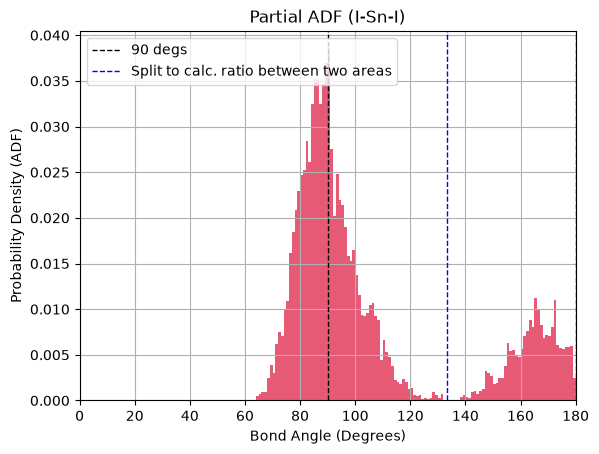

In [ ]:

# Vertical lines
plt.axvline(x=90, color='black', linestyle='--', linewidth=1, label='90 degs')
plt.axvline(x=180, color='black', linestyle='--', linewidth=1)

# Area ratio: find valley between peaks (restrict to 100-170° to avoid edges)
valley_mask = (bin_centers >= 100) & (bin_centers <= 170)
if np.any(valley_mask):
    valley_idx = np.argmin(probability_density[valley_mask]) + np.where(valley_mask)[0][0]
else:
    valley_idx = len(bin_centers) // 2  # fallback
plt.axvline(x=bin_centers[valley_idx], color='blue', linestyle='--', linewidth=1, label="Split to calc. ratio between two areas")

area_left = np.sum(probability_density[:valley_idx]) * bin_width
area_right = np.sum(probability_density[valley_idx:]) * bin_width
ratio = area_left / area_right if area_right > 0 else np.inf

print(f"Area (90° peak): {area_left:.4f}")
print(f"Area (180° peak): {area_right:.4f}")
print(f"Ratio (90/180): {ratio:.4f}")

# check how angles computed -> find where should second max be?

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.show()

As expected:
* peaks near 90 degrees and 180 degs
* 90 degs count 12 of 15 couple, 180 degs counts 3 of 15 ---> ratio = 4

In [ ]:
#---> normalization ok

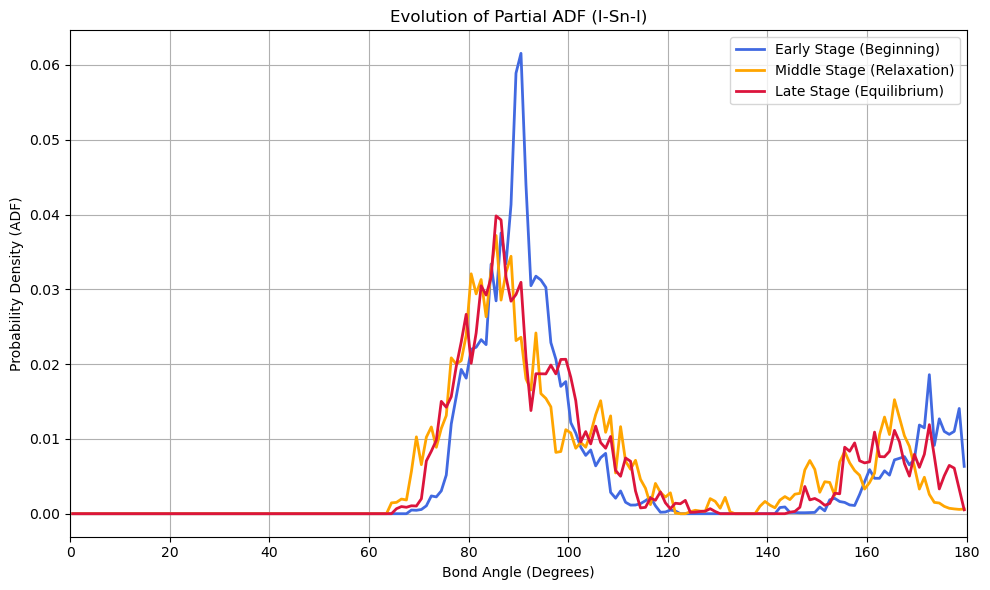

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

#cutoff = 3.5
center_element = 'Sn'
neighbor_element = 'I'
bins = 180
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

Tilting 

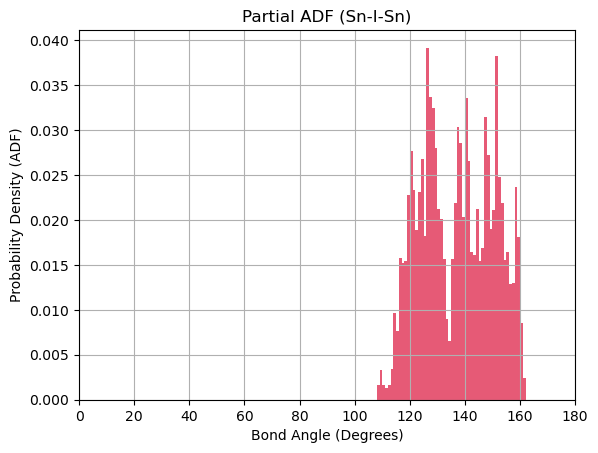

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')

cutoff = 3.5
center_element = 'I'
neighbor_element = 'Sn'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


In [ ]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

In [ ]:
# find theoretical angle prediction?

In [ ]:
# optional: do the same for N-C-C; or even with H...?

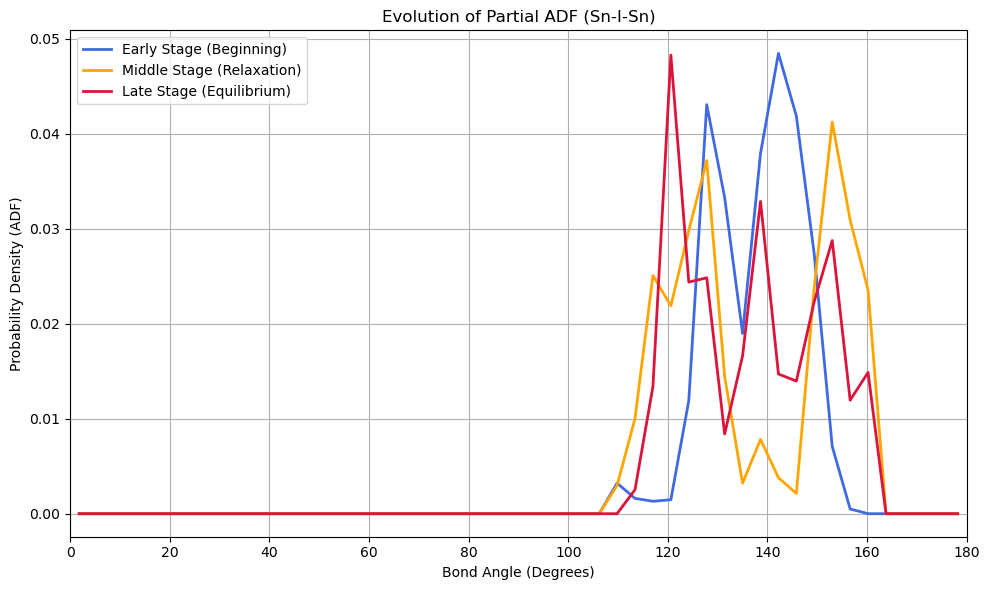

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# cutoff = 3.5
center_element = 'I'
neighbor_element = 'Sn'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

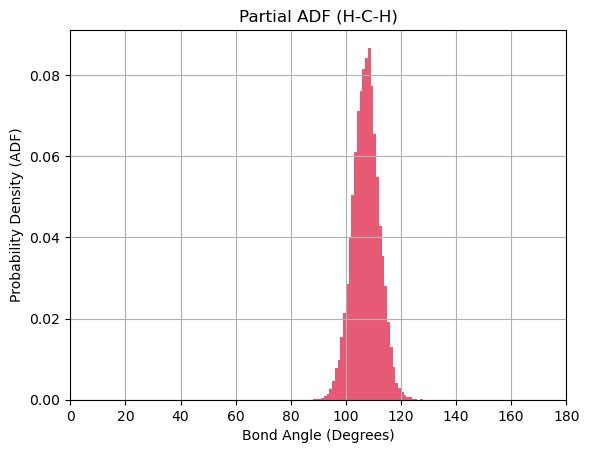

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')

cutoff = 1.5
center_element = 'C'
neighbor_element = 'H'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


In [ ]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

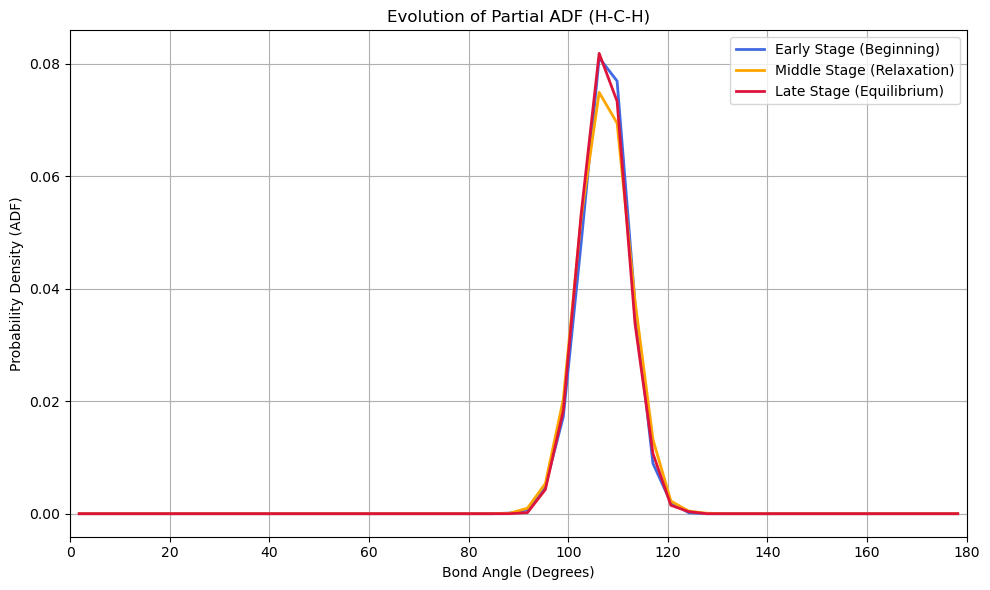

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

cutoff = 1.5
center_element = 'C'
neighbor_element = 'H'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

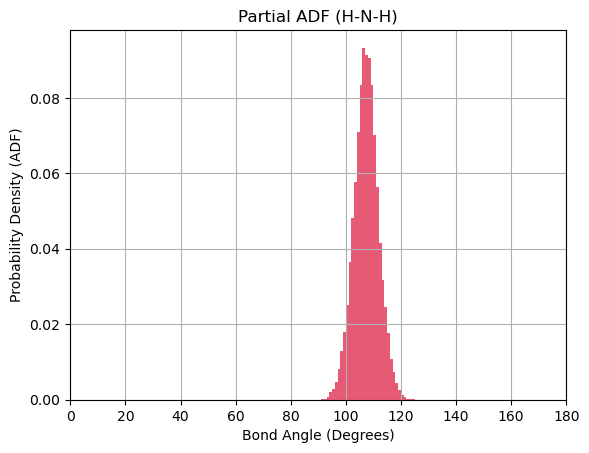

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')

# cutoff = 1.5
center_element = 'N'
neighbor_element = 'H'
bins = 180
total_counts = np.zeros(bins)
bin_edges = np.linspace(0, 180, bins + 1)

for atoms in images:
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx] == neighbor_element for idx in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        total_counts += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
total_angles = np.sum(total_counts)

if total_angles > 0:
    bin_width = bin_edges[1] - bin_edges[0]
    probability_density = total_counts / (total_angles * bin_width)
else:
    probability_density = total_counts


In [ ]:

plt.bar(bin_centers, probability_density, width=bin_width, color='crimson', alpha=0.7, edgecolor='none')
plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.show()

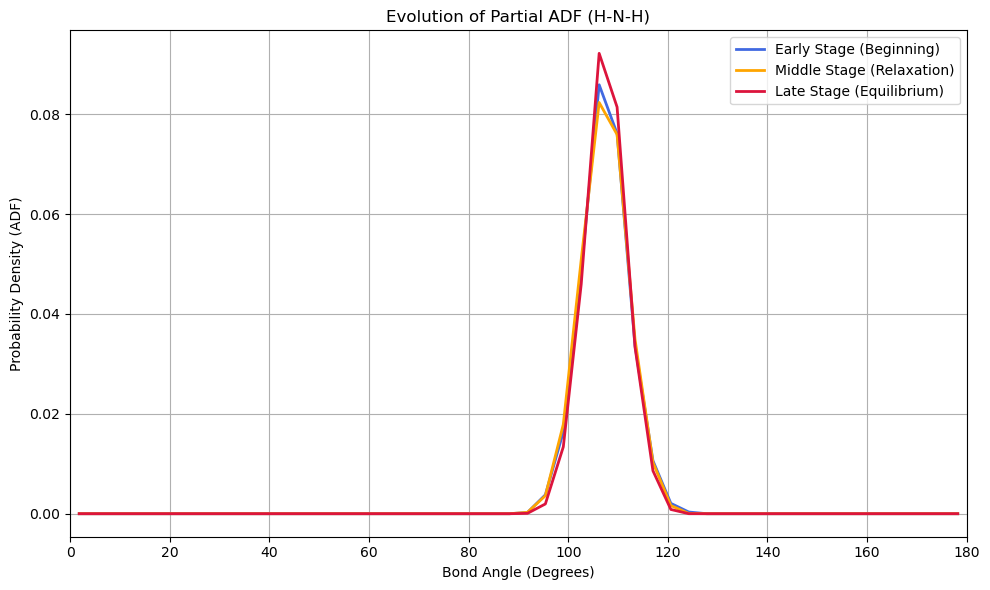

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# total_frames = len(images)

# cutoff = 1.5
center_element = 'N'
neighbor_element = 'H'
bins = 50
bin_edges = np.linspace(0, 180, bins + 1)

counts_early = np.zeros(bins)
counts_mid = np.zeros(bins)
counts_late = np.zeros(bins)

third = total_frames // 3
boundary_1 = third
boundary_2 = 2 * third

for idx, atoms in enumerate(images):
    frame_angles = []
    symbols = atoms.get_chemical_symbols()
    i, j, D = neighbor_list('ijD', atoms, cutoff=cutoff, self_interaction=False)
    
    for center_atom in range(len(atoms)):
        if symbols[center_atom] != center_element:
            continue
            
        mask = (i == center_atom)
        neighbor_indices = j[mask]
        vectors = D[mask]
        
        valid_mask = [symbols[idx_n] == neighbor_element for idx_n in neighbor_indices]
        valid_vectors = vectors[valid_mask]
        num_neighbors = len(valid_vectors)
        
        if num_neighbors >= 2:
            for idx1 in range(num_neighbors):
                for idx2 in range(idx1 + 1, num_neighbors):
                    v1 = valid_vectors[idx1]
                    v2 = valid_vectors[idx2]
                    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                    angle = np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0)))
                    frame_angles.append(angle)
                    
    if frame_angles:
        counts, _ = np.histogram(frame_angles, bins=bin_edges)
        if idx < boundary_1:
            counts_early += counts
        elif idx < boundary_2:
            counts_mid += counts
        else:
            counts_late += counts

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

sum_early = np.sum(counts_early)
sum_mid = np.sum(counts_mid)
sum_late = np.sum(counts_late)

pdf_early = counts_early / (sum_early * bin_width) if sum_early > 0 else counts_early
pdf_mid = counts_mid / (sum_mid * bin_width) if sum_mid > 0 else counts_mid
pdf_late = counts_late / (sum_late * bin_width) if sum_late > 0 else counts_late


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, pdf_early, color='royalblue', lw=2, label='Early Stage (Beginning)')
plt.plot(bin_centers, pdf_mid, color='orange', lw=2, label='Middle Stage (Relaxation)')
plt.plot(bin_centers, pdf_late, color='crimson', lw=2, label='Late Stage (Equilibrium)')

plt.xlabel('Bond Angle (Degrees)')
plt.ylabel('Probability Density (ADF)')
plt.title(f'Evolution of Partial ADF ({neighbor_element}-{center_element}-{neighbor_element})')
plt.grid(True)
plt.xlim(0, 180)
plt.legend()
plt.tight_layout()
plt.show()

## OACF-based analysis

(OACF - Orientational Autocorrelation Function)

It is a time-dependent statistical tool used to track how quickly molecules (or specific chemical bonds, functional groups, or dipole moments) rotate and change their spatial orientation over time due to thermal motion and local interactions.


Mathematically, it measures the correlation of a chosen unit vector $\hat{u}(t)$ describing a molecule's orientation at time $t$ with its initial orientation at an arbitrary starting time $t_0$. Most commonly, it is expressed using Legendre polynomials $P_n(x)$. The first-order ($n=1$) and second-order ($n=2$) OACFs are the most widely used:

$$C_1(t) = \langle \hat{u}(t_0) \cdot \hat{u}(t_0 + t) \rangle$$

$$C_2(t) = \langle P_2(\hat{u}(t_0) \cdot \hat{u}(t_0 + t)) \rangle = \frac{1}{2} \langle 3[\hat{u}(t_0) \cdot \hat{u}(t_0 + t)]^2 - 1 \rangle$$

Where the angular brackets $\langle \dots \rangle$ denote an ensemble average *over all molecules and time origins $t_0$* in your trajectory.


An OACF provides deep insight into the rotational dynamics and local environment of a system:

1. Extracting Rotational Relaxation Times: As time progresses, molecules collide and change directions, causing the correlation to decay toward zero. By fitting the OACF decay curve (often to an exponential or multi-exponential function like $e^{-t/\tau}$), it can be extracted the rotational correlation time ($\tau$). This tells you exactly how long it takes a molecule to lose memory of its initial orientation.

2. In a dense liquid or crowded environment: The OACF often exhibits a short-term oscillation or a slower, staggered decay. This reveals a "cage effect," where a molecule is trapped by its neighbors and bounces back and forth before successfully rotating.

3. Connecting Simulation to Spectroscopy Experiments: OACFs are the bridge between MD trajectories and actual physical laboratory measurements:$C_1(t)$ relates directly to Dielectric Relaxation spectroscopy and infrared (IR) absorption profiles, as it tracks the relaxation of total molecular dipole moments. $C_2(t)$ relates directly to Nuclear Magnetic Resonance (NMR) relaxation times ($T_1, T_2$), Raman scattering, and fluorescence anisotropy.

**In the program only C1 has been calculated.**

In the code, the orientation vectors (which represent the unit vectors $\hat{u}$) are calculated step-by-step through a combination of structural topology filtering, distance vector extraction, and normalization:

1. Identifying the Specific Molecular Bonds (pairs): Before calculating any vectors, the code needs to know which specific bonds it should track throughout the simulation. It does this by analyzing the very first frame (images[0]). It generates a neighbor list using a cutoff distance .It filters through all the neighboring atom pairs to find only the connections we need. The code assumes that these specific atoms stay bonded or associated in the same way across the entire simulation.

2. Extracting the Directional Vectors: Once the specific pairs are identified, the code loops through every single frame in MD trajectory and every identified molecular pair (m_idx).

3. Normalizing to Unit Vectors ($\hat{u}$): An OACF requires orientational vectors, meaning we only care about the direction the bond is pointing, not how long the bond is stretching or vibrating. To isolate just the direction, the code normalizes each raw displacement vector by dividing it by its own Euclidean length (norm)


In [48]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
num_frames = len(images)

first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=3.9, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'I' and symbols[idx_j] == 'Sn':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


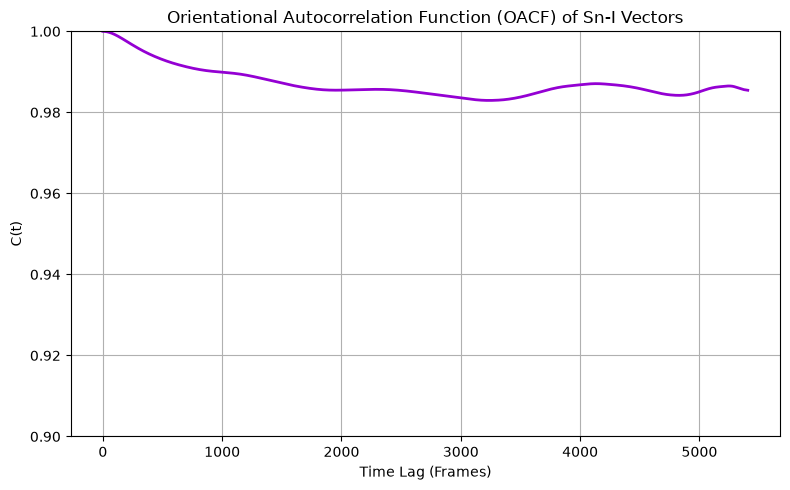

In [51]:

plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of Sn-I Vectors')
plt.grid(True)
plt.ylim(0.9, 1.)
plt.tight_layout()
plt.show()

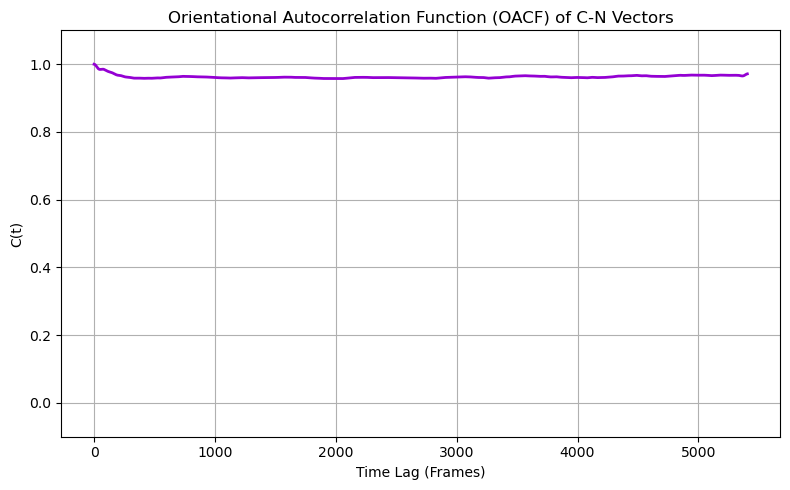

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# num_frames = len(images)

first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=1.6, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'C' and symbols[idx_j] == 'H':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of C-H Vectors')
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

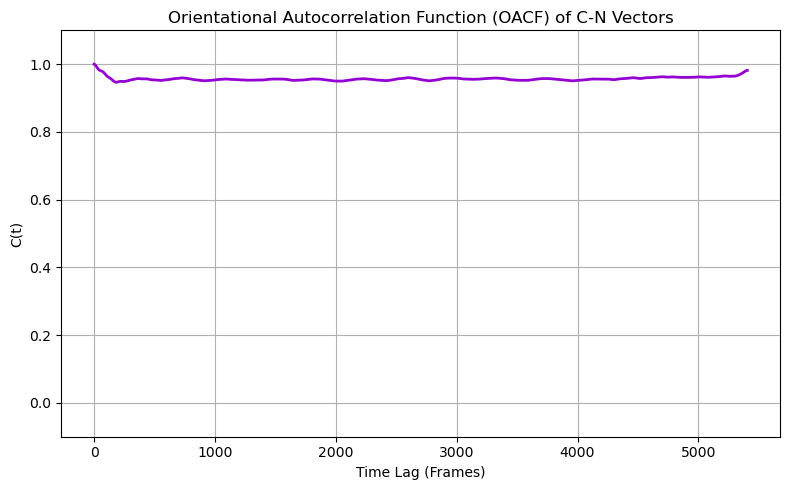

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from ase.io import read
# from ase.neighborlist import neighbor_list

# images = read('dataset_clean.extxyz', index=':')
# num_frames = len(images)

first_frame = images[0]
symbols = first_frame.get_chemical_symbols()
i, j = neighbor_list('ij', first_frame, cutoff=1.6, self_interaction=False)

pairs = []
for idx_i, idx_j in zip(i, j):
    if symbols[idx_i] == 'H' and symbols[idx_j] == 'N':
        pairs.append((idx_i, idx_j))

num_molecules = len(pairs)
vectors = np.zeros((num_frames, num_molecules, 3))

for f_idx, atoms in enumerate(images):
    for m_idx, (c_idx, n_idx) in enumerate(pairs):
        vec = atoms.get_distance(c_idx, n_idx, vector=True, mic=True)
        vectors[f_idx, m_idx] = vec / np.linalg.norm(vec)

oacf = np.zeros(num_frames)
for delta in range(num_frames):
    v_t = vectors[:num_frames - delta]
    v_tdelta = vectors[delta:]
    oacf[delta] = np.mean(np.sum(v_t * v_tdelta, axis=2))

time_axis = np.arange(num_frames)


In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(time_axis, oacf, color='darkviolet', lw=2)
plt.xlabel('Time Lag (Frames)')
plt.ylabel('C(t)')
plt.title('Orientational Autocorrelation Function (OACF) of H-N Vectors')
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

## VDOS analysis (via FFT)


Vibrational Density of States (VDOS), denoted as $g(\omega)$ ,tells you the distribution of vibrational modes (or frequencies) available to a system of atoms. 

Is a sort of "fingerprint spectrum" of atomic motion: it counts how many vibrational frequencies exist within a specific frequency interval. If a system has a high VDOS at a particular frequency $\omega$, it means many atoms are collective-vibrating, rocking, or stretching at that exact rate.

In Molecular Dynamics , the most common way to calculate the VDOS is by **taking the Fourier Transform of the Velocity Autocorrelation Function (VACF) of the atoms**:

$$g(\omega) = \int_{0}^{\infty} \langle \vec{v}(t_0) \cdot \vec{v}(t_0 + t) \rangle \cos(\omega t) \, dt$$

Where $\langle \vec{v}(t_0) \cdot \vec{v}(t_0 + t) \rangle$ is the VACF, tracking how atoms lose memory of their initial velocities due to interatomic collisions and forces.




VDOS connects atomic-scale trajectories directly to macroscopic and experimental properties:

#### 1. Connecting to Experimental Spectroscopy
VDOS is the direct simulation counterpart to experimental Inelastic Neutron Scattering (INS), Infrared (IR), and Raman spectroscopy. Plotting the VDOS from an MD simulation, the peaks you see correspond directly to the vibrational absorption bands measured in a physical laboratory.

#### 2. Identifying Structural Phases and Rigidity
Crystalline solids will show sharp, well-defined peaks in the VDOS, corresponding to specific phonon modes (lattice vibrations).


#### 3. Calculating Thermodynamic Properties
We can bypass complex free-energy simulations to estimate quantum-corrected thermodynamic quantities. Under the harmonic approximation, we can integrate the VDOS to compute:
* Vibrational Entropy ($S_{\text{vib}}$)
* Constant-volume Heat Capacity ($C_v$)
* Zero-point energy (ZPE)

#### 4. Uncovering Atomic-Scale Mechanisms
By computing the partial or projected VDOS (filtering the velocity vectors for only specific atom types), we can figure out exactly which atoms are responsible for which vibrational peaks. 

In the program:

Instead of calculating the Velocity Autocorrelation Function (VACF) in the time domain first, this script utilizes a numerical shortcut known as the **Wiener-Khinchin theorem**. This theorem proves that the power spectrum of a signal's Fourier Transform is mathematically identical to the Fourier Transform of its autocorrelation function. 


* 1. Approximating Velocities from Positions
Since raw `.extxyz` trajectory files often contain only atomic coordinates, the script first calculates the velocities using numerical differentiation

* 2. Setting Up the Frequency Domain: To map the final spectrum onto actual physical units, the code defines the frequency axis based on the total number of velocity frames and the real-time spacing between them, Using rfftfreq

* 3. The Fast Fourier Transform (FFT) and Power Spectrum: For the isolated velocities of a given element, the code shifts the entire trajectory from the time domain to the frequency domain using a Real Fast Fourier Transform along the time axis (axis=0).
Immediately after, it computes the Power Spectrum by squaring the absolute magnitude of the complex Fourier coefficients.
The power_spectrum array contains data partitioned by frames, atoms, and spatial coordinates (X, Y, Z). To get a single, scalar intensity value for each frequency.
* 4. Compiling the Total VDOS : the script sums over all atoms of that element and all three spatial dimensions


In [111]:
# in INCAR POTIM=0.5 ---> time step is 0.5 femtoseconds 

In [ ]:
timestep = 0.5

first_frame = images[0]
symbols = np.array(first_frame.get_chemical_symbols())
unique_elements = sorted(list(set(symbols)))

cell = first_frame.get_cell()
pbc = first_frame.get_pbc()

all_velocities = []
prev_pos = images[0].get_positions()
for atoms in images[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    all_velocities.append(step_disp / timestep)
    prev_pos = pos

all_velocities = np.array(all_velocities)
num_frames = len(all_velocities)
frequencies = np.fft.rfftfreq(num_frames, d=timestep)

print("Max v dataset:", np.max(np.abs(all_velocities)))

vdos_data = {}
total_vdos = np.zeros(len(frequencies))

for element in unique_elements:
    mask = (symbols == element)
    element_velocities = all_velocities[:, mask, :]

    fft_v = np.fft.rfft(element_velocities, axis=0)
    power_spectrum = np.abs(fft_v) ** 2
    pvdos = np.sum(power_spectrum, axis=(1, 2))

    vdos_data[element] = pvdos
    total_vdos += pvdos

Max v dataset: 0.04147999999999996


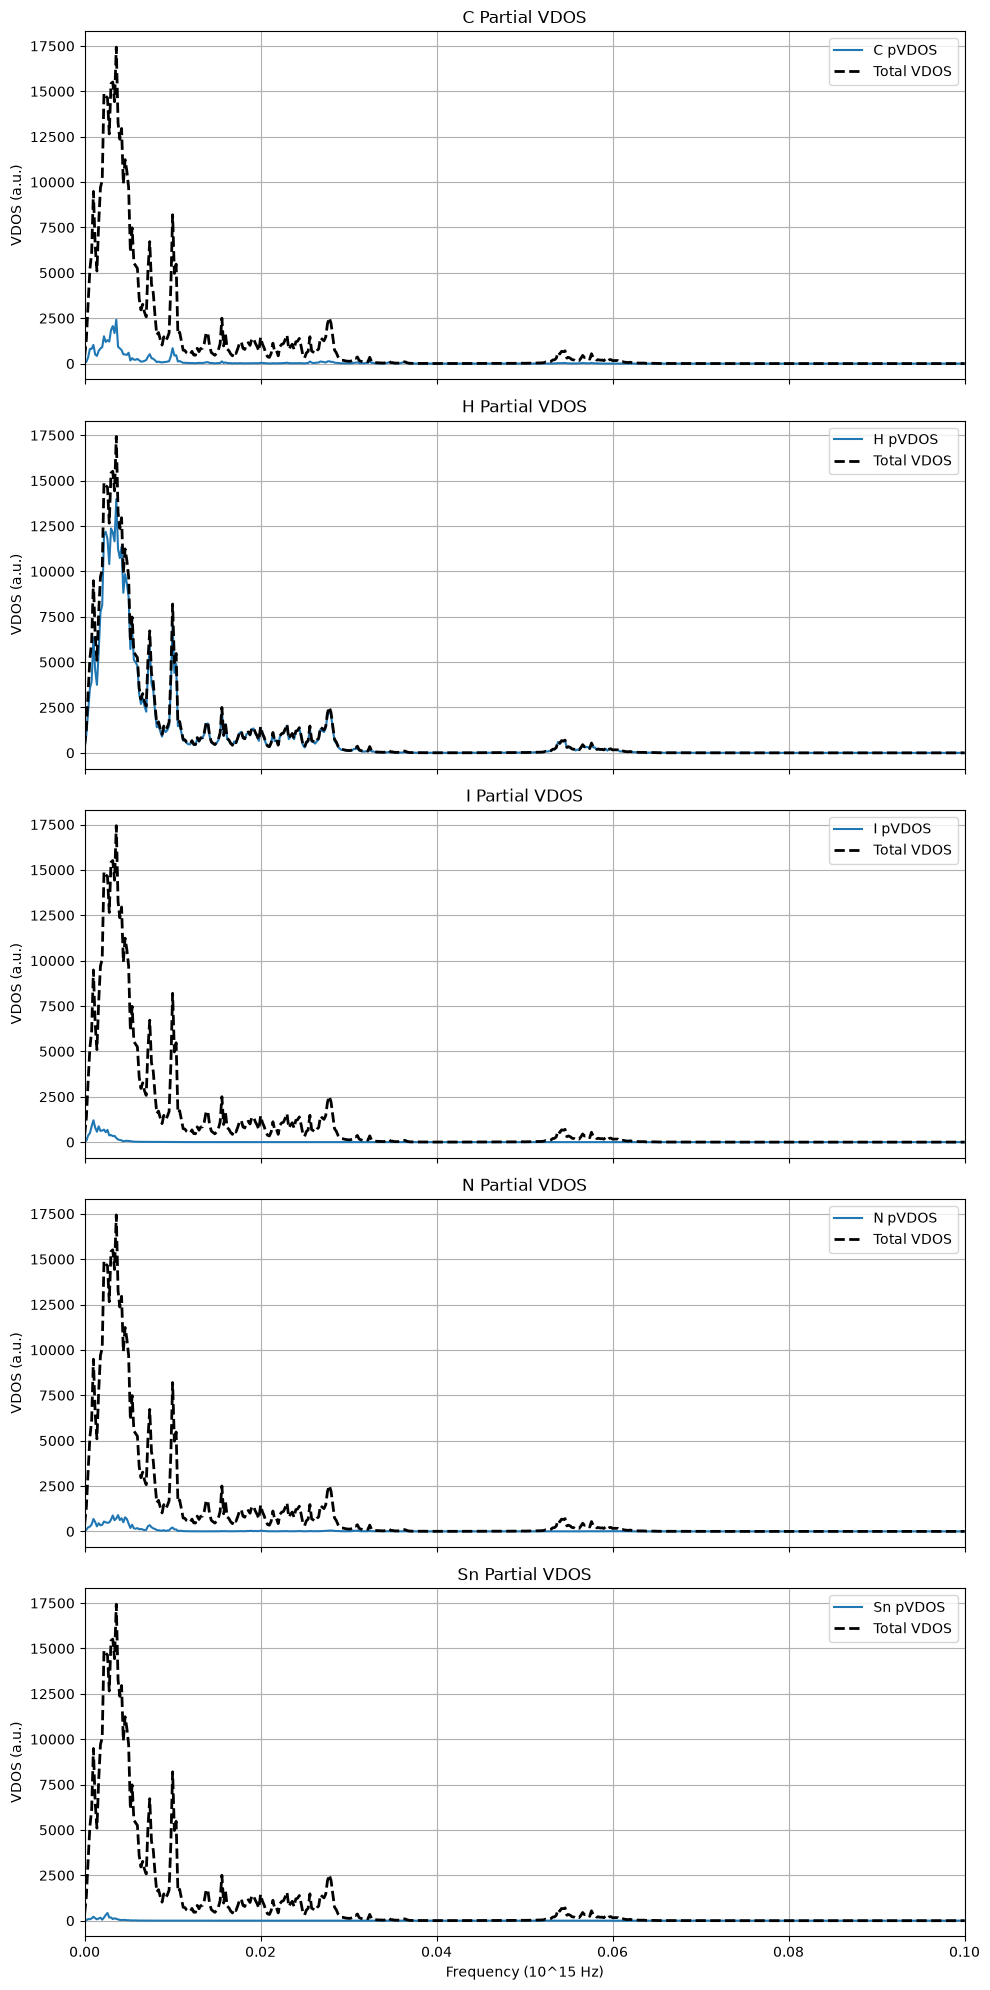

In [90]:
n_elements = len(unique_elements)
fig, axes = plt.subplots(n_elements, 1, figsize=(10, 4*n_elements), sharex=True)
if n_elements == 1:
    axes = [axes]

for ax, (element, pvdos) in zip(axes, vdos_data.items()):
    ax.plot(frequencies, pvdos, label=f'{element} pVDOS', lw=1.5)
    ax.plot(frequencies, total_vdos, label='Total VDOS', color='black', lw=2, linestyle='--')
    ax.set_ylabel('VDOS (a.u.)')
    ax.set_title(f'{element} Partial VDOS')
    ax.set_xlim(frequencies[0], 0.1)
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel('Frequency (10^15 Hz)') 
plt.tight_layout()
plt.show()

In [ ]:
#images = read('data/cleaned_dataset.extxyz', index=':')
# uses new data instead
timestep = 0.5

first_frame = images[0]
symbols = np.array(first_frame.get_chemical_symbols())
masses = first_frame.get_masses()
unique_elements = sorted(list(set(symbols)))

cell = first_frame.get_cell()
pbc = first_frame.get_pbc()

all_velocities = []
prev_pos = images[0].get_positions()
for atoms in images[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    all_velocities.append(step_disp / timestep)
    prev_pos = pos

all_velocities = np.array(all_velocities)
num_frames = len(all_velocities)
frequencies = np.fft.rfftfreq(num_frames, d=timestep)

vdos_data = {}
total_vdos = np.zeros(len(frequencies))

for element in unique_elements:
    mask = (symbols == element)
    element_velocities = all_velocities[:, mask, :]
    element_mass = masses[mask][0]

    fft_v = np.fft.rfft(element_velocities, axis=0)
    power_spectrum = np.abs(fft_v) ** 2
    pvdos = np.sum(power_spectrum, axis=(1, 2)) * element_mass

    vdos_data[element] = pvdos
    total_vdos += pvdos


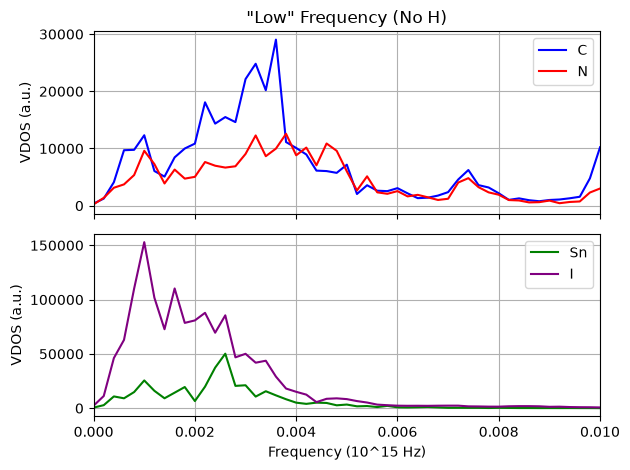

In [103]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
colors = {'C': 'blue', 'N': 'red', 'Sn': 'green', 'I': 'purple'}



# Top: C, N
for element in ['C', 'N']:
    if element in vdos_data:
        ax1.plot(frequencies, vdos_data[element], label=f'{element}', lw=1.5, color=colors[element])
ax1.set_ylabel('VDOS (a.u.)')
ax1.set_title('"Low" Frequency (No H)')
ax1.legend()
ax1.grid(True)

# Bottom: Sn, I
for element in ['Sn', 'I']:
    if element in vdos_data:
        ax2.plot(frequencies, vdos_data[element], label=f'{element}', lw=1.5, color=colors[element])
ax2.set_xlabel('Frequency (10^15 Hz)')
ax2.set_ylabel('VDOS (a.u.)')
ax2.legend()
ax2.grid(True)

ax2.set_xlim([0., 0.01])
plt.tight_layout()
plt.show()

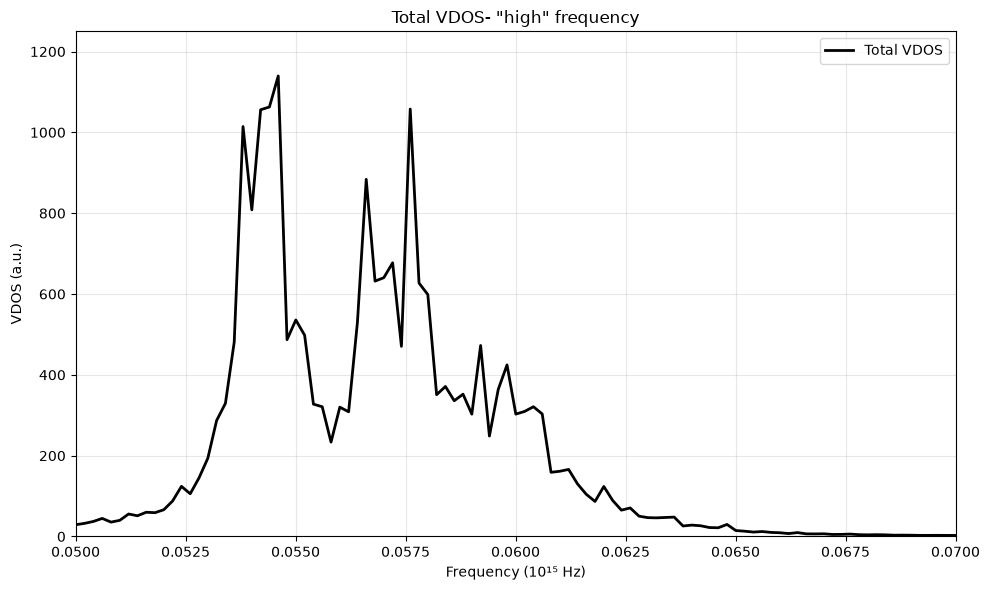

In [107]:
# --- Plot total VDOS in a specific frequency range ---
plt.figure(figsize=(10, 6))

# Plot total VDOS
plt.plot(frequencies, total_vdos, color='black', lw=2, label='Total VDOS')

# Set x-axis limits to the desired range (0.05 to 0.07 in 10^15 Hz)
plt.xlim(0.05, 0.07)
plt.ylim([0., 1250])

plt.xlabel('Frequency (10¹⁵ Hz)')
plt.ylabel('VDOS (a.u.)')
plt.title('Total VDOS- "high" frequency')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Theoretical expected peaks (order of magnitude) for a hybrid perovskite (source: various papers):
* inorganic 10^(-3) THz -> ok
* organic 10^(-3) THz but higher than inorganic; -> ok
* organic + inorganic: 10^(-3) to 10^(-2) THz; -> ok (see total VDOS)
* organic (cations): 10^(-2) THz -> ok (see especially C, H)
* organic, C-H and N-H: around 9 * 10^(-2) THz (see total in interval above, completely due to H)

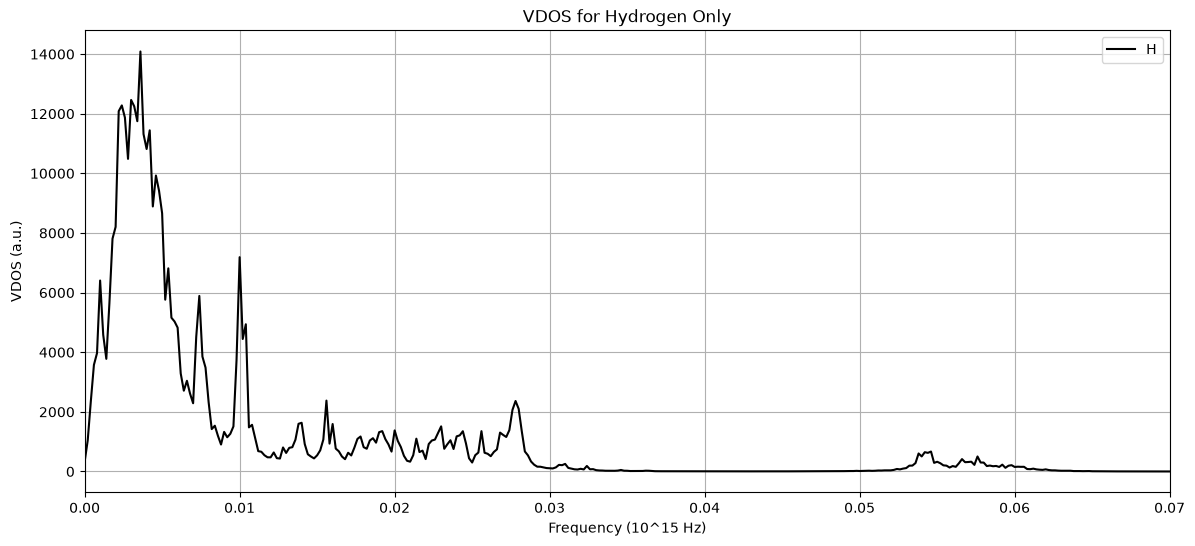

In [98]:
plt.figure(figsize=(14,6))
if 'H' in vdos_data:
    plt.plot(frequencies, vdos_data['H'], label='H', lw=1.5, color='black')
#plt.xscale('log')
#plt.ylim([400_000, 800_000])
plt.xlim([0.,0.07])
plt.xlabel('Frequency (10^15 Hz)')
plt.ylabel('VDOS (a.u.)')
plt.title('VDOS for Hydrogen Only')
plt.legend()
plt.grid(True)
#plt.tight_layout()
plt.show()

## MSD analysis

(Mean squared displacement)

In [81]:
# import os
# # import numpy as np
# # import matplotlib.pyplot as plt
# from ase.io import iread

ORGANIC_SYMBOLS = {"H", "C", "N"}
INORGANIC_SYMBOLS = {"Sn", "I"}

input_file = my_full_file

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found.")
    exit(1)

times = []
msd_full = []
msd_org = []
msd_inorg = []
msd_h = []

rmsd_full = []
rmsd_org = []
rmsd_inorg = []
rmsd_h = []

ref_pos_full = None
ref_pos_org = None
ref_pos_inorg = None
ref_pos_h = None

for index, atoms in enumerate(iread(input_file, index=":")):
    times.append(index)
    
    #splitting indexes
    org_indices = [atom.index for atom in atoms if atom.symbol in ORGANIC_SYMBOLS]
    inorg_indices = [atom.index for atom in atoms if atom.symbol in INORGANIC_SYMBOLS]
    h_indices = [atom.index for atom in atoms if atom.symbol == "H"]
    
    #taking position
    pos_full = atoms.get_positions()
    pos_org = pos_full[org_indices] if org_indices else np.array([])
    pos_inorg = pos_full[inorg_indices] if inorg_indices else np.array([])
    pos_h = pos_full[h_indices] if h_indices else np.array([])
    
    #starting point
    if index == 0:
        ref_pos_full = pos_full.copy()
        ref_pos_org = pos_org.copy() if pos_org.size > 0 else None
        ref_pos_inorg = pos_inorg.copy() if pos_inorg.size > 0 else None
        ref_pos_h = pos_h.copy() if pos_h.size > 0 else None

###############################################################################
# NEW CORRECTION:
# unwrapped position accumulators, initialized at frame 0
    if index == 0:
        prev_pos_full = pos_full.copy()
        unwrapped_pos_full = pos_full.copy()
    else:
        step_disp = pos_full - prev_pos_full
        step_disp, _ = find_mic(step_disp, atoms.get_cell(), pbc=atoms.get_pbc())
        unwrapped_pos_full += step_disp
        prev_pos_full = pos_full.copy()
    unwrapped_pos_org = unwrapped_pos_full[org_indices] if org_indices else np.array([])
    unwrapped_pos_inorg = unwrapped_pos_full[inorg_indices] if inorg_indices else np.array([])
    unwrapped_pos_h = unwrapped_pos_full[h_indices] if h_indices else np.array([])


    
    #mean squared deviation
    #sq_dist_full = np.sum((pos_full - ref_pos_full) ** 2, axis=1)
    sq_dist_full = np.sum((unwrapped_pos_full - ref_pos_full) ** 2, axis=1)
###################################################################################
    msd_full.append(np.mean(sq_dist_full))
    
    if ref_pos_org is not None and pos_org.size > 0:
        sq_dist_org = np.sum((unwrapped_pos_org - ref_pos_org) ** 2, axis=1) # similar correction
        msd_org.append(np.mean(sq_dist_org))
    else:
        msd_org.append(0.0)
        
    if ref_pos_inorg is not None and pos_inorg.size > 0:
        sq_dist_inorg = np.sum((unwrapped_pos_inorg - ref_pos_inorg) ** 2, axis=1) # similar corr
        msd_inorg.append(np.mean(sq_dist_inorg))
    else:
        msd_inorg.append(0.0)

    if ref_pos_h is not None and pos_h.size > 0:
        sq_dist_h = np.sum((unwrapped_pos_h - ref_pos_h) ** 2, axis=1) # similar corr
        msd_h.append(np.mean(sq_dist_h))
    else:
        msd_h.append(0.0)

    #root mean squared deviation
    rmsd_full.append(np.sqrt(np.mean(sq_dist_full)))
    
    if ref_pos_org is not None and pos_org.size > 0:
        rmsd_org.append(np.sqrt(np.mean(sq_dist_org)))
    else:
        rmsd_org.append(0.0)
        
    if ref_pos_inorg is not None and pos_inorg.size > 0:
        rmsd_inorg.append(np.sqrt(np.mean(sq_dist_inorg)))
    else:
        rmsd_inorg.append(0.0)

    if ref_pos_h is not None and pos_h.size > 0:
        rmsd_h.append(np.sqrt(np.mean(sq_dist_h)))
    else:
        rmsd_h.append(0.0)

print(f"Processed {len(times)} frames successfully.")

#saving result
times = np.array(times)
msd_full = np.array(msd_full)
msd_org = np.array(msd_org)
msd_inorg = np.array(msd_inorg)
msd_h = np.array(msd_h)

rmsd_full = np.array(rmsd_full)
rmsd_org = np.array(rmsd_org)
rmsd_inorg = np.array(rmsd_inorg)
rmsd_h = np.array(rmsd_h)


Processed 10000 frames successfully.


Comparison plot saved as 'trajectory_dynamics_comparison.png'


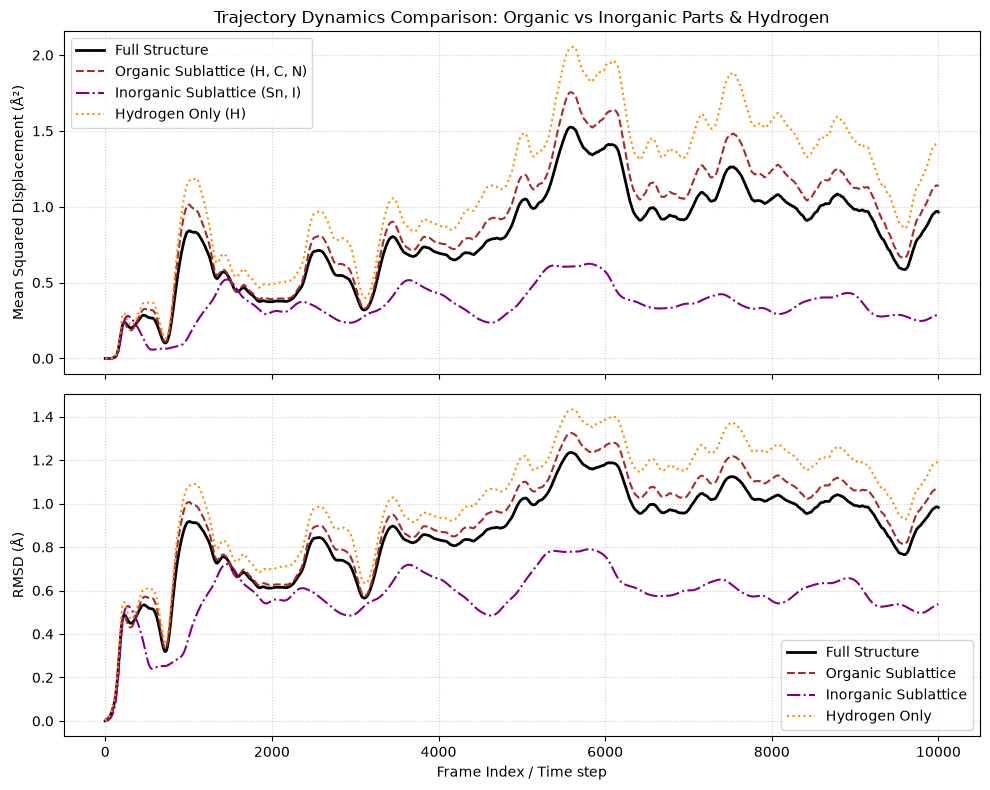

In [ ]:

#plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top Plot: MSD
ax1.plot(times, msd_full, label="Full Structure", color="black", linewidth=2)
ax1.plot(times, msd_org, label="Organic Sublattice (H, C, N)", color="brown", linestyle="--")
ax1.plot(times, msd_inorg, label="Inorganic Sublattice (Sn, I)", color="purple", linestyle="-.")
ax1.plot(times, msd_h, label="Hydrogen Only (H)", color="darkorange", linestyle=":")
ax1.set_ylabel("Mean Squared Displacement (Å²)")
ax1.set_title("Trajectory Dynamics Comparison: Organic vs Inorganic Parts & Hydrogen")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# Bottom Plot: RMSD
ax2.plot(times, rmsd_full, label="Full Structure", color="black", linewidth=2)
ax2.plot(times, rmsd_org, label="Organic Sublattice", color="brown", linestyle="--")
ax2.plot(times, rmsd_inorg, label="Inorganic Sublattice", color="purple", linestyle="-.")
ax2.plot(times, rmsd_h, label="Hydrogen Only", color="darkorange", linestyle=":")
ax2.set_ylabel("RMSD (Å)")
ax2.set_xlabel("Frame Index / Time step")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("trajectory_dynamics_comparison.png", dpi=300)
#print("Comparison plot saved as 'trajectory_dynamics_comparison.png'")
plt.show()

In [ ]:



 # ------------------------------------------------------------
# 2. Initialise dictionaries
# ------------------------------------------------------------
times = []
msd_elements = {}
rmsd_elements = {}
ref_positions = {}          # initial unwrapped positions per element
prev_pos_full = None        # for frame‑to‑frame displacement
unwrapped_pos_full = None   # cumulative unwrapped positions

# ------------------------------------------------------------
# 3. Loop over frames
# ------------------------------------------------------------
for index, atoms in enumerate(iread(input_file, index=":")):
    times.append(index)

    # Current wrapped positions and symbols
    pos_full = atoms.get_positions()
    symbols = np.array(atoms.get_chemical_symbols())
    unique_elements = sorted(set(symbols))

    # ---- First frame: set up references ----
    if index == 0:
        # Initialise dictionaries for all elements
        for element in unique_elements:
            msd_elements[element] = []
            rmsd_elements[element] = []
        # Set reference positions (will be overwritten after unwrapping)
        # We will set them after unwrapping the first frame

        # Initialise unwrapping
        prev_pos_full = pos_full.copy()
        unwrapped_pos_full = pos_full.copy()   # at frame 0, unwrapped = wrapped

        # Now store reference positions for each element from the unwrapped frame 0
        for element in unique_elements:
            mask = (symbols == element)
            ref_positions[element] = unwrapped_pos_full[mask].copy()

    else:
        # ---- Compute frame‑to‑frame displacement with MIC ----
        step_disp = pos_full - prev_pos_full
        step_disp, _ = find_mic(step_disp, atoms.get_cell(), pbc=atoms.get_pbc())
        unwrapped_pos_full += step_disp
        prev_pos_full = pos_full.copy()

    # ---- For each element, compute MSD/RMSD from unwrapped positions ----
    for element in unique_elements:
        mask = (symbols == element)
        if np.any(mask):
            # Unwrapped positions for this element
            unwrapped_pos_element = unwrapped_pos_full[mask]
            # Reference positions (initial unwrapped)
            ref_pos_element = ref_positions[element]

            # Squared displacements
            sq_dist = np.sum((unwrapped_pos_element - ref_pos_element) ** 2, axis=1)
            mean_sq_dist = np.mean(sq_dist)

            msd_elements[element].append(mean_sq_dist)
            rmsd_elements[element].append(np.sqrt(mean_sq_dist))
        else:
            # Should not happen because we only loop over elements present
            msd_elements[element].append(0.0)
            rmsd_elements[element].append(0.0)

# ------------------------------------------------------------
# 4. Convert to numpy arrays for plotting
# ------------------------------------------------------------
times = np.array(times)
for element in msd_elements:
    msd_elements[element] = np.array(msd_elements[element])
    rmsd_elements[element] = np.array(rmsd_elements[element])

print(f"Processed {len(times)} frames successfully. Elements: {list(msd_elements.keys())}")
 

Processed 10000 frames successfully. Elements: [np.str_('C'), np.str_('H'), np.str_('I'), np.str_('N'), np.str_('Sn')]


Comparison plot saved as 'element_dynamics_comparison.png'


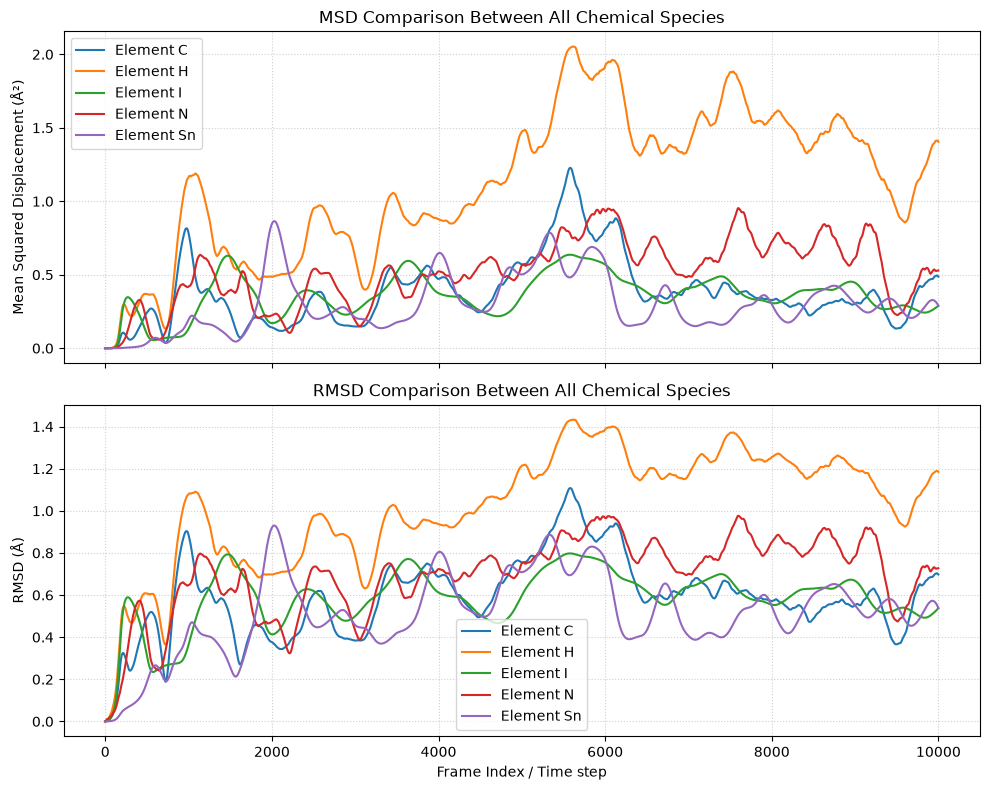

In [ ]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for element in msd_elements.keys():
    ax1.plot(times, msd_elements[element], label=f"Element {element}", linewidth=1.5)
    ax2.plot(times, rmsd_elements[element], label=f"Element {element}", linewidth=1.5)

ax1.set_ylabel("Mean Squared Displacement (Å²)")
ax1.set_title("MSD Comparison Between All Chemical Species")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.set_ylabel("RMSD (Å)")
ax2.set_xlabel("Frame Index / Time step")
ax2.set_title("RMSD Comparison Between All Chemical Species")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("element_dynamics_comparison.png", dpi=300)
#print("Comparison plot saved as 'element_dynamics_comparison.png'")
plt.show()

## Temperature cross-check

$$T = \frac{2 \cdot E_k}{3 \cdot N \cdot k_B}$$

### Calculating Instantaneous Temperature from Trajectory Positions

* Numerical Velocity Extraction with Periodic Boundary Conditions (PBC): Since raw trajectory files (like .extxyz) typically only contain atomic coordinates, velocities (as before) must be reconstructed using finite differences ($\Delta v = \Delta x / \Delta t$)

* Displacement Calculation: For each consecutive frame, the script calculates the displacement vector ($\Delta p$) for every atom. Minimum Image Convention (MIC): If an atom crosses a periodic boundary between two frames, a naive subtraction would yield a massive, artificial displacement vector stretching across the entire simulation box. The function find_mic() wraps the displacement back into the box, ensuring we get the true, shortest physical distance traveled by the atom.

* Computing the Total Kinetic Energy ($E_k$): Using the converted velocities and atomic masses, the script computes the instantaneous kinetic energy of the system for each frame

* Applying the Equipartition Theorem for Temperature:  According to the Equipartition Theorem, the total kinetic energy of a classical system at thermal equilibrium is directly proportional to its temperature and its degrees of freedom (DOF)



In [86]:
# from ase.geometry import find_mic
# import ase.units as units
# import numpy as np

timestep_in_fs = 0.5  

images_v = images#[1000:]

all_velocities = []
for i in range(len(images_v) - 1):
    delta_p = images_v[i+1].get_positions() - images_v[i].get_positions()
    delta_p, _ = find_mic(delta_p, images[i].get_cell(), pbc=images_v[i].get_pbc())
    all_velocities.append(delta_p / timestep_in_fs)

all_velocities = np.array(all_velocities)
#atomi_move = 100
#dynamic_dof = 3 * atomi_move - 3
N_atoms = len(images[0])
dynamic_dof = 3 * N_atoms - 3
temperatures = []

for i, atoms in enumerate(images_v[:-1]):
    masses = atoms.get_masses()
    v_ase = all_velocities[i] / units.fs
    ek = 0.5 * np.sum(masses[:, np.newaxis] * (v_ase ** 2))
    t_instantaneous = (2 * ek) / (dynamic_dof * units.kB)
    temperatures.append(t_instantaneous)

mean_temperature = np.mean(temperatures)
print(f"Calculated mean temperature: {mean_temperature:.2f} K")

Calculated mean temperature: 234.34 K


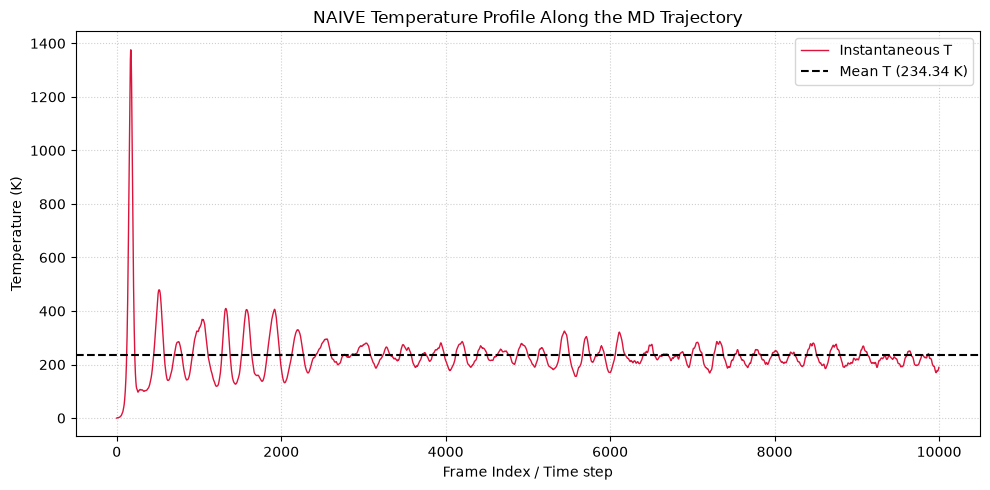

In [87]:
# import numpy as np
# import matplotlib.pyplot as plt

time_steps = np.arange(len(temperatures))

plt.figure(figsize=(10, 5))
plt.plot(time_steps, temperatures, color="crimson", linewidth=1, label="Instantaneous T")
plt.axhline(y=mean_temperature, color="black", linestyle="--", linewidth=1.5, label=f"Mean T ({mean_temperature:.2f} K)")

plt.xlabel("Frame Index / Time step")
plt.ylabel("Temperature (K)")
plt.title("NAIVE Temperature Profile Along the MD Trajectory")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("temperature_profile.png", dpi=300)
plt.show()

Temperature is more ore less 50 degrees smaller than temperature from outcar

In [ ]:
# NOTE (by Libero): the following part seems ad-hoc and incorrect to me; running it for a different VASP simulatio still gave wrong (too high in this case) temperature; the above part to calculate Temperature is indeed probably correct, and lower result than the expected 300 K is probably due to finite-difference calculation artifact (ie, H oscillates too fast for its full movement to be seen in the 15 fs timestep; see 'Temperature' section in 'Convergence check' part for more details)

### Adaptive Degrees of Freedom (DoF) and Temperature Calculation

This script introduces an automated approach to calculating system temperature compared to the previous version. Instead of blindly hardcoding the number of moving atoms, this code dynamically filters out static atoms using a kinetic energy threshold technique. This ensures that the applied Degrees of Freedom (DoF) are physically accurate for the specific simulation setup.

 1. Frame Stripping and Velocity Reconstruction Just like the previous script.

2. Calculating the Mean Kinetic Energy per Atom 

3. Logarithmic Scaling and Sensitivity Filtering: 

threshold = min_log + sensitivity * (max_log - min_log)

moving_atoms = np.sum(log_kinetic_energies > threshold)

4. Computing Corrected DoF and Instantaneous Temperature: With the dynamically discovered count of moving atoms, the script calculates the proper degrees of freedom:$$N_{\text{dof}} = 3 N_{\text{moving}} - 3$$It then loops back through the trajectory frames, computes the total instantaneous kinetic energy ($E_k$), and applies the Equipartition Theorem to calculate the final mean temperature in Kelvin.

In [ ]:
# formula justified bc: remove 3 dofs bc translation of center of mass

In [43]:
# from ase.geometry import find_mic
# import ase.units as units
# import numpy as np

timestep_in_fs = 0.5  
sensitivity = 0.1815

print(f"Total frames read from file: {len(images)}")
selected_images = images#[1000:]

all_velocities = []
for i in range(len(selected_images) - 1):
    delta_p = selected_images[i+1].get_positions() - selected_images[i].get_positions()
    delta_p, _ = find_mic(delta_p, selected_images[i].get_cell(), pbc=selected_images[i].get_pbc())
    all_velocities.append(delta_p / timestep_in_fs)

all_velocities = np.array(all_velocities)

masses = selected_images[0].get_masses()
velocities_ase = all_velocities / units.fs
squared_velocities = np.sum(velocities_ase**2, axis=2)
kinetic_energies = 0.5 * masses[np.newaxis, :] * squared_velocities
mean_kinetic_energy_per_atom = np.mean(kinetic_energies, axis=0)

log_kinetic_energies = np.log10(mean_kinetic_energy_per_atom + 1e-15)

min_log = np.min(log_kinetic_energies)
max_log = np.max(log_kinetic_energies)
threshold = min_log + sensitivity * (max_log - min_log)

moving_atoms = np.sum(log_kinetic_energies > threshold)
dynamic_dof = 3 * moving_atoms - 3

print("\n--- CONFIGURATION DETAILS ---")
print(f"Total atoms in cell: {len(selected_images[0])}")
print(f"Dynamically detected moving atoms: {moving_atoms}")
print(f"Applied degrees of freedom (DoF): {dynamic_dof}")
print("-------------------------------\n")

temperatures = []
for i, atoms in enumerate(selected_images[:-1]):
    current_masses = atoms.get_masses()
    v_ase = all_velocities[i] / units.fs
    ek = 0.5 * np.sum(current_masses[:, np.newaxis] * (v_ase ** 2))
    t_instantaneous = (2 * ek) / (dynamic_dof * units.kB)
    temperatures.append(t_instantaneous)

mean_temperature=np.mean(temperatures)
print(f"Calculated mean temperature: {mean_temperature:.2f} K")

Total frames read from file: 10000

--- CONFIGURATION DETAILS ---
Total atoms in cell: 100
Dynamically detected moving atoms: 47
Applied degrees of freedom (DoF): 138
-------------------------------

Calculated mean temperature: 504.34 K


In [33]:
! echo "Actual simulation temperature (K):" && cat $INCAR_FILE | grep "TEBEG" 

Actual simulation temperature (K):
TEBEG = 300


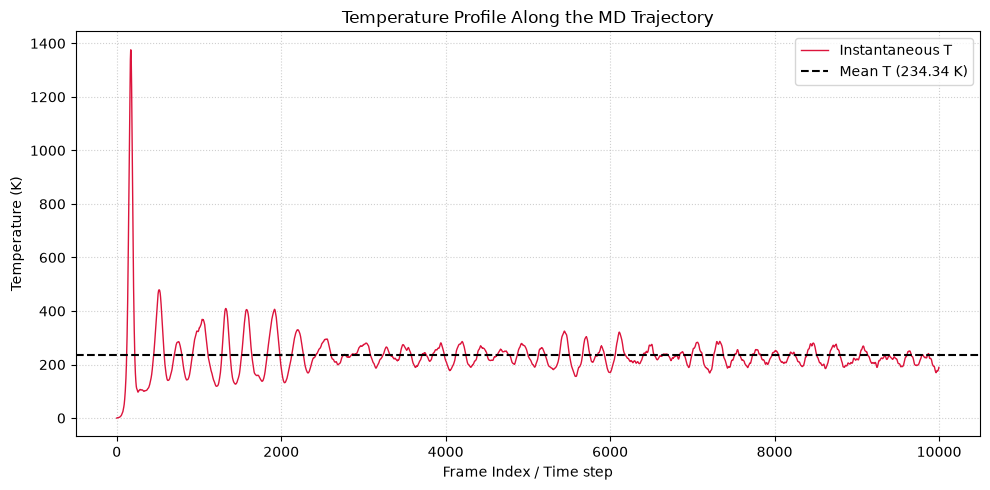

In [110]:

plt.figure(figsize=(10, 5))
plt.plot(time_steps, temperatures, color="crimson", linewidth=1, label="Instantaneous T")
plt.axhline(y=mean_temperature, color="black", linestyle="--", linewidth=1.5, label=f"Mean T ({mean_temperature:.2f} K)")

plt.xlabel("Frame Index / Time step")
plt.ylabel("Temperature (K)")
plt.title("Temperature Profile Along the MD Trajectory")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("temperature_profile.png", dpi=300)
plt.show()

In [ ]:
### USES NEW DATA:

## Convergence check

In [ ]:
from pymbar import timeseries
# study theory of this??

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [12]:
def check_equilibration(observable, name, dt=1):
    """
    observable: 1D array, one scalar value per frame
    Returns t0 (equilibration frame), g (statistical inefficiency),
    Neff (effective uncorrelated sample count)
    """
    t0, g, Neff = timeseries.detect_equilibration(observable)
    print(f"[{name}] t0 = {t0} (frame {t0*dt}), "
          f"g = {g:.2f}, N_eff = {Neff:.1f} / {len(observable)}")
    return t0, g, Neff

In [ ]:
# # same as before, but on all frames and ALL ATOMS:
timestep_in_fs = 0.5

all_velocities = []
for i in range(len(images) - 1):
    delta_p = images[i+1].get_positions() - images[i].get_positions()
    delta_p, _ = find_mic(delta_p, images[i].get_cell(), pbc=images[i].get_pbc())
    all_velocities.append(delta_p / timestep_in_fs)
all_velocities = np.array(all_velocities)

N_atoms = len(images[0])
dof = 3 * N_atoms - 3   # only remove 3 for center-of-mass translation

temperatures = []
for i, atoms in enumerate(images[:-1]):
    m = atoms.get_masses()
    v_ase = all_velocities[i] / units.fs
    ek = 0.5 * np.sum(m[:, np.newaxis] * v_ase**2)
    temperatures.append((2 * ek) / (dof * units.kB))
temperatures = np.array(temperatures) 

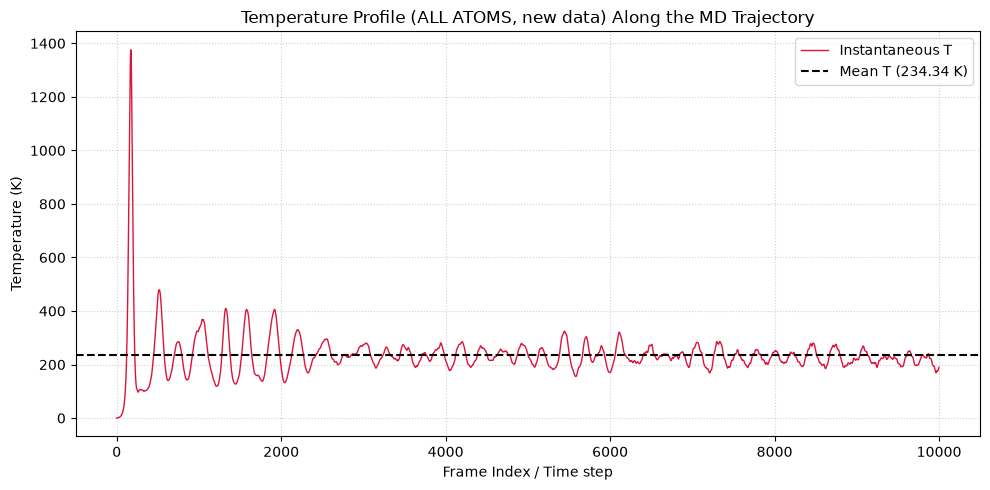

In [ ]:
time_steps=np.arange(len(images))[:-1]
mean_temperature=np.mean(temperatures)

plt.figure(figsize=(10, 5))
plt.plot(time_steps, temperatures, color="crimson", linewidth=1, label="Instantaneous T")
plt.axhline(y=mean_temperature, color="black", linestyle="--", linewidth=1.5, label=f"Mean T ({mean_temperature:.2f} K)")

plt.xlabel("Frame Index / Time step")
plt.ylabel("Temperature (K)")
plt.title("Temperature Profile (ALL ATOMS, new data) Along the MD Trajectory")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
#plt.savefig("temperature_profile.png", dpi=300)
plt.show()

In [41]:
#print(moving_atoms) # sanity check:
print(temperatures[-1])
print(mean_temperature)

189.41832698336205
234.3396822041716


In [ ]:
! grep "TEBEG" $INCAR_FILE # actual temperature

TEBEG = 300


In [ ]:
# Partial temperature by species

symbols=np.array(atoms.get_chemical_symbols())
for element in ['Sn', 'I', 'N', 'C', 'H']:
    mask = symbols == element
    n = mask.sum()
    dof_el = 3 * n  # no COM subtraction needed for a diagnostic split
    T_el = []
    for i in range(len(all_velocities)):
        v = all_velocities[i][mask] / units.fs
        m = masses[mask]
        ek = 0.5 * np.sum(m[:, np.newaxis] * v**2)
        T_el.append(2*ek / (dof_el * units.kB))
    print(element, np.mean(T_el[-2000:])) # last 2000 frames

Sn 528.21248798176
I 641.7873151426795
N 302.1830132701717
C 221.48328564352266
H 66.97267765109277


In [ ]:
# hydrogen apparent speed is suppressed the most using finite- differences to compute velocoties
# - inherent limitation in the simulation: time step of 15 fs too small to catch some H oscillations, probably

In [109]:
# diagnostics (check if undected jumps between cells - everything ok)

# for element in ['Sn', 'I', 'N', 'C', 'H']:
#     mask = symbols == element
#     v_el = all_velocities[:, mask, :] * units.fs  # back to Å/fs actually already in Å/fs before /units.fs division... adjust as needed
#     speed = np.linalg.norm(all_velocities[:, mask, :], axis=2)  # Å/fs
#     print(element, "max |v| (Å/fs):", speed.max(), "at frame", np.unravel_index(speed.argmax(), speed.shape))

In [ ]:

# --- Apply to independent scalar observables ---
# 1. Temperature (already computed above as `temperatures`)
t0_T, g_T, Neff_T = check_equilibration(np.array(temperatures), "Temperature", dt=1) 


[Temperature] t0 = 167 (frame 167), g = 64.78, N_eff = 151.8 / 9999


In [53]:
rmax = 3.9
nbins = 1000
window_size = 20
total_frames = len(images)

g_max_history = []
fwhm_history = []
time_steps = []

for start_idx in range(0, total_frames - window_size + 1, window_size):
    window_rdfs = []
    for atoms in images[start_idx : start_idx + window_size]:
        rdf_vals, distances = get_rdf(atoms, rmax=rmax, nbins=nbins)
        window_rdfs.append(rdf_vals)
    window_avg_rdf = np.mean(window_rdfs, axis=0)

    max_idx = np.argmax(window_avg_rdf)
    g_max = window_avg_rdf[max_idx]
    half_max = g_max / 2.0

    left_indices = np.where(window_avg_rdf[:max_idx] < half_max)[0]
    right_indices = np.where(window_avg_rdf[max_idx:] < half_max)[0]
    if len(left_indices) > 0 and len(right_indices) > 0:
        fwhm = distances[max_idx + right_indices[0]] - distances[left_indices[-1]]
    else:
        fwhm = np.nan

    g_max_history.append(g_max)
    fwhm_history.append(fwhm)
    time_steps.append(start_idx + window_size // 2)

g_max_history = np.array(g_max_history)
fwhm_history = np.array(fwhm_history)

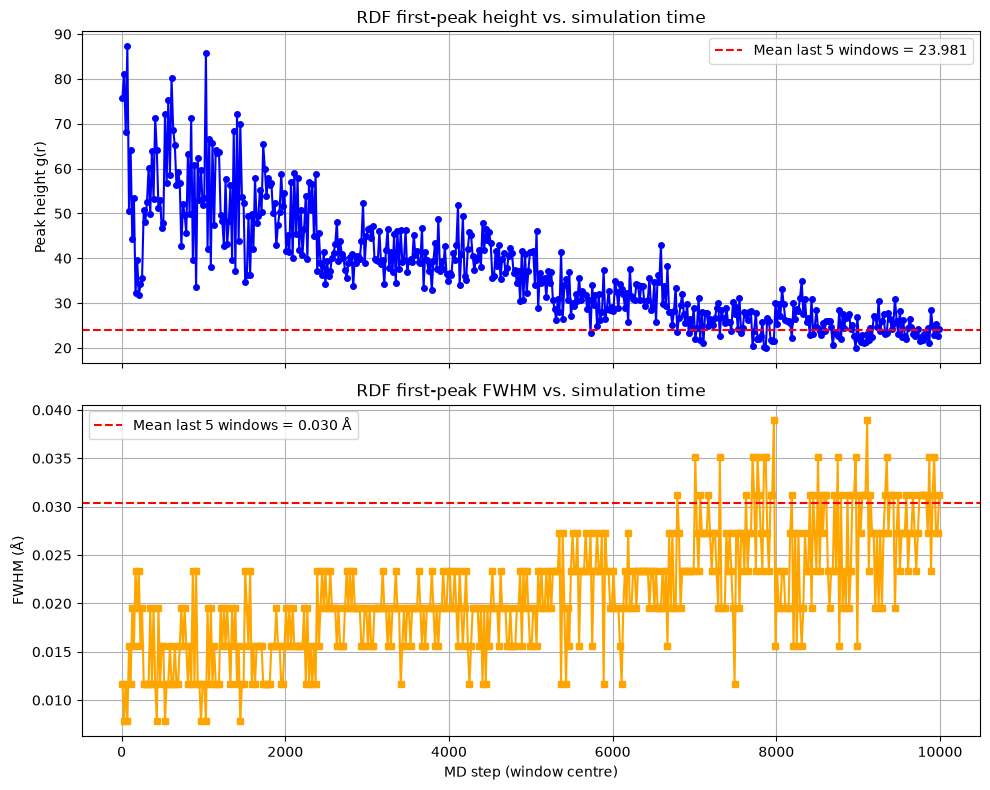

In [54]:
# Assuming g_max_history, fwhm_history, time_steps are defined as above

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Peak height (g_max) ---
ax1.plot(time_steps, g_max_history, 'o-', color='blue', lw=1.5, markersize=4)
ax1.axhline(np.mean(g_max_history[-5:]), color='red', linestyle='--', 
            label=f"Mean last 5 windows = {np.mean(g_max_history[-5:]):.3f}")
ax1.set_ylabel('Peak height g(r)')
ax1.grid(True)
ax1.legend()
ax1.set_title('RDF first‐peak height vs. simulation time')

# --- FWHM ---
ax2.plot(time_steps, fwhm_history, 's-', color='orange', lw=1.5, markersize=4)
ax2.axhline(np.mean(fwhm_history[-5:]), color='red', linestyle='--',
            label=f"Mean last 5 windows = {np.mean(fwhm_history[-5:]):.3f} Å")
ax2.set_xlabel('MD step (window centre)')
ax2.set_ylabel('FWHM (Å)')
ax2.grid(True)
ax2.legend()
ax2.set_title('RDF first‐peak FWHM vs. simulation time')

plt.tight_layout()
plt.show()

In [58]:

# 2. RDF peak height / width (already computed as g_max_history, fwhm_history)
t0_gmax, g_gmax, Neff_gmax = check_equilibration(np.array(g_max_history), "g_max", dt=window_size)
t0_fwhm, g_fwhm, Neff_fwhm = check_equilibration(np.array(fwhm_history), "FWHM", dt=window_size)


[g_max] t0 = 420 (frame 8400), g = 1.82, N_eff = 44.5 / 500
[FWHM] t0 = 342 (frame 6840), g = 4.19, N_eff = 37.9 / 500


In [63]:
cell = images[0].get_cell()
pbc = images[0].get_pbc()

# accumulate unwrapped displacement frame-to-frame
unwrapped_disp = np.zeros_like(images[0].get_positions())
msd_full_mic = [0.0]

prev_pos = images[0].get_positions()
for atoms in images[1:]:
    pos = atoms.get_positions()
    step_disp = pos - prev_pos
    step_disp, _ = find_mic(step_disp, cell, pbc=pbc)
    unwrapped_disp += step_disp
    msd_full_mic.append(np.mean(np.sum(unwrapped_disp**2, axis=1)))
    prev_pos = pos

msd_full_mic = np.array(msd_full_mic)

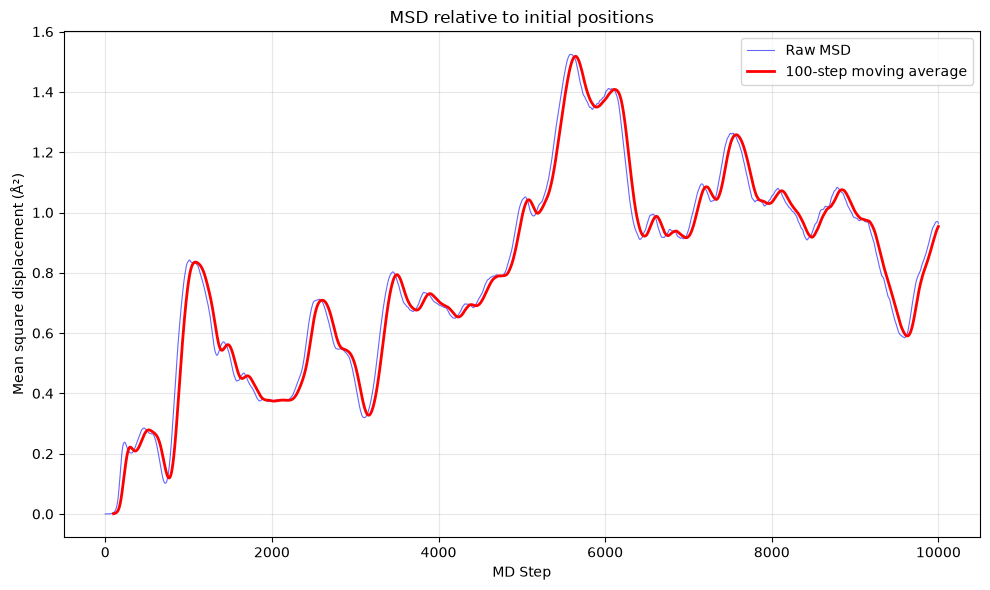

In [108]:
steps = np.arange(len(msd_full_mic))

# Optional: moving average to smooth noise
window = 100  # adjust based on your total steps
if len(msd_full_mic) > window:
    moving_avg = np.convolve(msd_full_mic, np.ones(window)/window, mode='valid')
    steps_avg =steps[window-1:]

plt.figure(figsize=(10, 6))
plt.plot(steps, msd_full_mic, lw=0.8, alpha=0.6, color='blue', label='Raw MSD')
if len(msd_full_mic) > window:
    plt.plot(steps_avg, moving_avg, lw=2, color='red', label=f'{window}-step moving average')

# Optional: linear fit to the last half to estimate diffusivity
# half = len(msd_full_mic)//2
# slope, intercept = np.polyfit(steps[half:], msd_full_mic[half:], 1)
# plt.plot(steps, slope*steps + intercept, 'k--', lw=1.5,
#          label=f'Fit (last 50%): slope = {slope:.4f} Å²/step')

plt.xlabel('MD Step')
plt.ylabel('Mean square displacement (Å²)')
plt.title('MSD relative to initial positions')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [66]:

# 3. Total MSD (already computed as msd_full_mic)
t0_msd, g_msd, Neff_msd = check_equilibration(msd_full_mic, "MSD (full)")


[MSD (full)] t0 = 5954 (frame 5954), g = 480.62, N_eff = 8.4 / 10000


In [75]:
# also: energies from outcar
outcar_images=read(outcar_file, index=':')

energies = np.array([atoms.get_potential_energy() for atoms in outcar_images])


In [76]:

# Apply the equilibration test
t0_E, g_E, Neff_E = check_equilibration(energies, "Total Energy", dt=1)


[Total Energy] t0 = 86 (frame 86), g = 205.61, N_eff = 48.2 / 10000


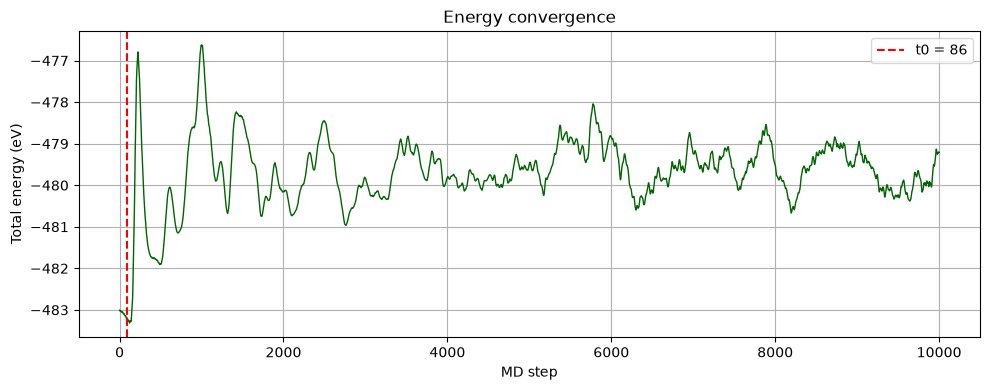

In [77]:

# Plot energy alongside for visual check
plt.figure(figsize=(10, 4))
plt.plot(energies, lw=1, color='darkgreen')
plt.axvline(t0_E, color='red', linestyle='--', label=f't0 = {t0_E}')
plt.xlabel('MD step')
plt.ylabel('Total energy (eV)')
plt.title('Energy convergence')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
t0_T_frame     = t0_T
t0_gmax_frame  = t0_gmax * window_size
t0_fwhm_frame  = t0_fwhm * window_size
t0_msd_frame   = t0_msd   # already frame-based, assuming MIC-corrected version
t0_E_frame = t0_E          # energy steps are directly frame indices

t0_consensus = max(t0_T_frame, t0_gmax_frame, t0_fwhm_frame, t0_msd_frame, t0_E_frame)
print(f"Consensus equilibration frame: {t0_consensus}")

Consensus equilibration frame: 8400


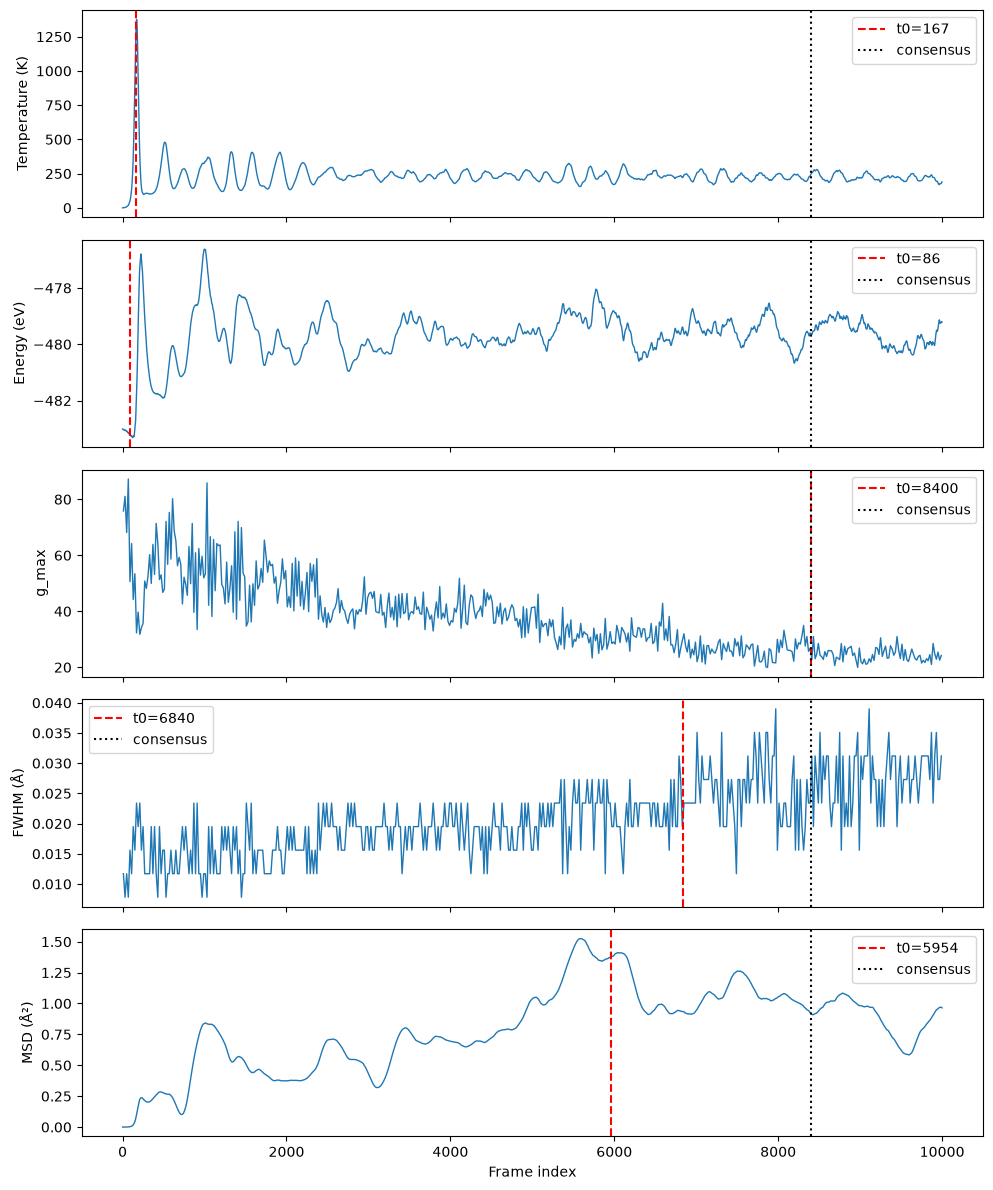

In [ ]:
fig, axs = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

x_T    = np.arange(len(temperatures))
x_E    = np.arange(len(energies))
x_msd  = np.arange(len(msd_full_mic))
x_gmax = time_steps
x_fwhm = time_steps

t0s = [t0_T, t0_E, t0_gmax_frame, t0_fwhm_frame, t0_msd]
data_list = [temperatures, energies, g_max_history, fwhm_history, msd_full_mic]
x_list = [x_T, x_E, x_gmax, x_fwhm, x_msd]
names = ["Temperature (K)", "Energy (eV)", "g_max", "FWHM (Å)", "MSD (Å²)"]

for ax, x, data, name, t0 in zip(axs, x_list, data_list, names, t0s):
    ax.plot(x, data, lw=1)
    ax.axvline(t0, color="red", ls="--", label=f"Frame index = {t0}")
    ax.axvline(t0_consensus, color="black", ls=":", label="consensus")
    ax.set_ylabel(name)
    ax.legend()

axs[-1].set_xlabel("Frame index")
plt.tight_layout()
plt.show()